In [27]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

from aind_vr_foraging_analysis.utils.parsing import data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib.patches as mpatches
# Plotting libraries
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FixedLocator, FuncFormatter

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

color1='#d95f02'
color2='#1b9e77'
color3="#7570b3"
color4='yellow'
odor_list_color = [color1, color2, color3, color4]
import matplotlib.lines as mlines

pdf_path = r'Z:\scratch\vr-foraging\sessions'
results_path = r'C:\Users\tiffany.ona\OneDrive - Allen Institute\Documents\VR foraging\experiments\batch 8 - reversals\results'

color_dict_label = {'InterSite': '#808080',
            'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
            'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
            'PatchB': '#d95f02','PatchA': '#7570b3', 
            'PatchC': '#1b9e77',
            'Alpha-pinene': '#1b9e77', 
            'Methyl Butyrate': '#7570b3', 
            'Amyl Acetate': '#d95f02', 
            'Fenchone': '#7570b3', 
            '1-pentanol': '#1b9e77',
            'Ethyl Butyrate': '#d95f02',
            'Dipropyl sulfide': '#7570b3',
            'Hexanal': '#1b9e77',
            'Pentyl acetate': '#d95f02',
            'S': color1,
            'D': color2,
            'N': color3,   
            'Do': color1,
            'None': color4
            }

label_dict = {**{
"InterSite": '#808080',
"InterPatch": '#b3b3b3'}, 
            **color_dict_label}
import os
import re
sns.set_context('talk')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
def average_velocity_odor_sites_reversal(all_epochs: pd.DataFrame, stream_data: pd.DataFrame, window: list = [-2,5], save=False):
    window = [-2, 5]
    odor_sites = all_epochs.loc[all_epochs['label'] == 'OdorSite']

    # Create figure and axes
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)

    # Get trial summary
    trial_summary = plotting.trial_collection(
        odor_sites[['mouse', 'session', 'label', 'site_number', 'odor_label',
                    'last_visit','patch_number', 'patch_label', 'odor_sites',
                    'block', 'is_choice', 'is_reward']],
        stream_data.encoder_data, aligned='index', window=window
    )

    # Filter once for site_number == 0
    summary_filtered = trial_summary[trial_summary['site_number'] == 0]

    # Labels and axes
    patch_labels = ['S', 'D', 'N']

    for i, block in enumerate(odor_sites.block.unique()):
        for ax, patch_label in zip(axes[i], patch_labels):
            data = summary_filtered[(summary_filtered['patch_label'] == patch_label)]
            sns.lineplot(
                data=data.loc[data['block'] == block],
                x='times',
                y='speed',
                hue='odor_sites',
                palette='coolwarm',
                linewidth=1,
                ax=ax,
                legend=False,
                errorbar='sd', 
                alpha = 0.6
            )
            try:
                odor_titles = data.loc[data['block'] == block]['odor_label'].unique()[0]
            except:
                odor_titles = data['odor_label'].unique()[0]
                
            ax.set_title(odor_titles, color = color_dict_label[patch_label])
            ax.set_ylabel("Velocity (cm/s)")
            ax.set_xlabel("Time after odor onset (s)", fontsize=10)
            ax.set_ylim(-13, 60)
            ax.set_yticks([0, 20, 40,60])
            ax.set_xlim(window)
            ax.hlines(8, window[0], window[1], color="black", linewidth=1, linestyles="dashed")
            ax.vlines(0, -13, 60, color="black", linewidth=1, linestyles="dashed")

    # Add manual legend
    handles = [
        plt.Line2D([0], [0], color=color_dict_label[label], label=label)
        for label in ['S','D','N']
    ]

    axes[1][-1].legend(handles=handles, title="Odor label", bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.despine()
    plt.suptitle(f"Velocity traces {data.mouse.unique()[0]}")
    plt.tight_layout()
    if save:
        save.savefig(fig)
        plt.close(fig)
    else:
        plt.show()  

In [29]:
def segmented_raster_vertical(reward_sites: pd.DataFrame,
    color_dict_label: dict = {
        "Ethyl Butyrate": "#d95f02",
        "Alpha-pinene": "#1b9e77",
        "Amyl Acetate": "#7570b3"
    }, 
    save = False):
    
    patch_number = len(reward_sites.patch_number.unique())
    number_odors = len(reward_sites["odor_label"].unique())

    # Make second row proportional to the number of odors
    list_odors = []
    for odor in reward_sites.odor_label.unique():
        list_odors.append(
            reward_sites.loc[reward_sites.odor_label == odor].patch_number.nunique()
        )
    grid = (np.array(list_odors) / patch_number) * number_odors

    fig = plt.figure(figsize=(14, 8))
    gs = GridSpec(2, number_odors, width_ratios=grid)

    for index, row in reward_sites.iterrows():
        ax1 = plt.subplot(gs[0, 0:number_odors])
        if row["is_reward"] == 1 and row["is_choice"] == True:
            color = "steelblue"
        elif row["is_reward"] == 0 and row["is_choice"] == True:
            color = "pink"
            if row["reward_probability"] <= 0:
                color = "crimson"
        else:
            if row["reward_probability"] <= 0:
                color = "black"
            else:
                color = "lightgrey"

        # ax1.barh(int(row['patch_number']), left=row['site_number'], height=1, width=1, color=color, edgecolor='darkgrey', linewidth=0.5)
        ax1.bar(
            int(row["patch_number"]),
            bottom=row["site_number"],
            height=1,
            width=1,
            color=color,
            edgecolor="darkgrey",
            linewidth=0.5,
        )
        ax1.set_xlim(-1, max(reward_sites.patch_number) + 1)          
        ax1.set_xlabel("Patch number")
        ax1.set_ylabel("Site number")

        # ax1.bar(int(row['patch_number']), bottom = -1, height=0.5, width = 1, color=patch_color, edgecolor='black', linewidth=0.5)
        ax1.scatter(
            row["patch_number"],
            -0.25,
            color=color_dict_label[row["odor_label"]],
            marker="^",
            s=35,
            edgecolor="black",
            linewidth=0.0,
        )

    if reward_sites.block.nunique() > 1:
        change_index = reward_sites[reward_sites.block.diff() != 0]['patch_number'].values[1]
        ax1.axvline(change_index-0.5, color='black', linestyle='--', label='Change')
            
    odors = []
    for odor in reward_sites["patch_label"].unique():
        odors.append(
            mpatches.Patch(
                color=color_dict_label[odor],
                label=(
                    str(odor)
                ),
            )
        )

    label_2 = mpatches.Patch(color="steelblue", label="Harvest, rewarded")
    label_3 = mpatches.Patch(color="crimson", label="Harvest, no reward, depleted")
    label_4 = mpatches.Patch(color="lightgrey", label="Leave, not depleted")
    label_5 = mpatches.Patch(color="black", label="Leave, depleted")
    label_6 = mpatches.Patch(color="pink", label="Harvest, no reward, probabilitic")

    odors.extend([label_2, label_3, label_6, label_4, label_5])
    ax1.set_ylim(-1, max(reward_sites.site_number) + 1)

    # Create subplots dynamically in the bottom row (row index 1)
    unique_patches = reward_sites["odor_label"].unique()
    axes = [plt.subplot(gs[1, i]) for i in range(number_odors)]

    # Now loop over each odor and axis
    for ax, odor_label in zip(axes, unique_patches):
        selected_sites = reward_sites.loc[reward_sites.odor_label == odor_label]
        previous_active = 0
        value = 0
        blocks = selected_sites['block'].drop_duplicates().values
        for i in range(len(blocks) - 1):
            # Find where the transition happens
            idx = selected_sites[selected_sites['block'] == blocks[i]].patch_number.nunique()
            ax.axvline(idx + 0.5, color='black', linestyle='--', label='Block Change' if i == 0 else None)

            # Label each side of the transition
            for offset, block in zip([-1, 1], [blocks[i], blocks[i + 1]]):
                labels = selected_sites[selected_sites['block'] == block]['patch_label'].unique()
                if len(labels):
                    ax.text(idx + offset, y=3, s=labels[0], ha='right' if offset < 0 else 'left')

        for index, row in selected_sites.iterrows():
            # Choose the color of the site
            if row["is_reward"] == 1 and row["is_choice"] == True:
                color = "steelblue"
            elif row["is_reward"] == 0 and row["is_choice"] == True:
                color = "pink"
                if row['patch_label'] == 'N':
                    color = "crimson"
                elif row['patch_label'] == 'D' and row['site_number'] >= 3:
                    color = "crimson"
                elif row['patch_label'] == 'S' and row['site_number'] >= 1:
                    color = "crimson"
            else:
                if row['patch_label'] == 'N':
                    color = "black"
                elif row['patch_label'] == 'D' and row['site_number'] >= 3:
                    color = "black"
                elif row['patch_label'] == 'S' and row['site_number'] >= 1:
                    color = "black"
                else:
                    color = "lightgrey"

            ax.set_title(odor_label)

            if row["patch_number"] != previous_active:
                value += 1
                previous_active = row["patch_number"]
            ax.bar(
                value,
                bottom=row["site_number"],
                height=1,
                width=1,
                color=color,
                edgecolor="darkgrey",
                linewidth=0.5,
            )
            ax.set_xlim(-1, selected_sites.patch_number.nunique() + 1)
            ax.set_ylim(-0.5, reward_sites.site_number.max() + 1)
            ax.set_ylabel("Site number")
            ax.set_xlabel("Patch number")

    fig.tight_layout()
    plt.legend(handles=odors, loc='best', bbox_to_anchor=(0.75, 1), fontsize=12, ncol=1)
    sns.despine()
    if save:
        save.savefig(fig)
        plt.close(fig)
    else:
        plt.show()  


In [30]:
def average_velocity_traces_reversal(all_epochs: pd.DataFrame, stream_data, window: list = [-2,5], save=False):
    odor_sites = all_epochs.loc[all_epochs['label'] == 'OdorSite']

    # Create figure and axes
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)

    # Get trial summary
    trial_summary = plotting.trial_collection(
        odor_sites[['mouse', 'session', 'label', 'site_number', 'odor_label',
                    'last_visit','patch_number', 'patch_label', 'odor_sites',
                    'block', 'is_choice', 'is_reward']],
        stream_data.encoder_data, aligned='index', window=window
    )

    # Filter once for site_number == 0
    summary_filtered = trial_summary[trial_summary['site_number'] == 0]

    # Labels and axes
    patch_labels = ['S', 'D', 'N']

    for ax, patch_label in zip(axes, patch_labels):
        data = summary_filtered[summary_filtered['patch_label'] == patch_label]
        
        sns.lineplot(
            data=data,
            x='times',
            y='speed',
            hue='odor_label',
            style='block',
            palette=color_dict_label,
            ax=ax,
            legend=False,
            errorbar='sd', 
            alpha=0.6,
        )
        
        odor_titles = data['odor_label'].unique()[0]
        # title = ', '.join(odor_titles) if len(odor_titles) > 0 else patch_label
        ax.set_title(odor_titles)

        ax.set_ylabel("Velocity (cm/s)")
        ax.set_xlabel("Time after odor onset (s)")
        ax.set_ylim(-13, 60)
        ax.set_yticks([0, 20, 40, 60])
        ax.set_xlim(window)
        ax.hlines(8, window[0], window[1], color="black", linewidth=1, linestyles="dashed")
        ax.vlines(0, -13, 60, color="black", linewidth=1, linestyles="dashed")

    # Add manual legend
    handles = [
        plt.Line2D([0], [0], color=color_dict_label[label], label=label)
        for label in ['S','D','N']
    ]
    block_handles = [
        mlines.Line2D([], [], color='black', linestyle="solid", label=f"Block 0"),
        mlines.Line2D([], [], color='black', linestyle="dashed", label=f"Block 1")
    ]

    axes[-1].legend(handles=handles + block_handles, title="Odor label", bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.despine()
    plt.suptitle(f"Velocity traces {data.mouse.unique()[0]}")
    plt.tight_layout()
    if save:
        save.savefig(fig)
        plt.close(fig)
    else:
        plt.show()  


In [31]:
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text or "null" in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

## **Compute a summary of reversal and experimental history for this group of mice**

In [32]:
import aind_vr_foraging_analysis.data_io as data_io

def parse_summary_session(session_path):
    df = {}
    data = {}
    # Work around the change in the folder structure
    if "behavior" in os.listdir(session_path):
        session_path_behavior = session_path / "behavior"
    else:
        session_path_behavior = session_path
        
    if "other" in os.listdir(session_path):
        session_path_config = session_path / "other"
    else:
        session_path_config = session_path
        
        # Load config old version
    if "Logs" in os.listdir(session_path_behavior):
        data["config"] = data_io.ConfigSource(path=session_path_behavior / "Logs", name="config", autoload=True)
        
    rig = data['config'].streams.rig_input.data
    task_logic = data['config'].streams.tasklogic_input.data
    
    df['rig'] = rig['rig_name']
    try:
        df['stage'] = task_logic['stage_name']
    except:
        df['stage'] = 'no_stage'
    df['VAST'] = str(session_path)[10:]
    df['s3'] = str(session_path)[27:]
    return df

In [33]:
date_string = "2026-6-1"

mouse_list = ['846440', '846441', '846439', '849495', '863680', '863700', '863703', '863704', '863696']
df = pd.DataFrame(columns=['mouse', 'stage', 'reversal', 'start', 'stop', 'VAST', 's3'])
for mouse in mouse_list:
    print(f"Loading {mouse}...")
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        when='on_or_after',
    )

    for session_path in session_paths:
        new_row = parse_summary_session(session_path)
        new_row['reversal'] = 'reversal' in new_row['stage']
        match = re.search(r'set(\d+)', new_row['stage'])
        new_row['start'] = match.group(1) if match else None
        if new_row['reversal']:
            match = re.search(r'reversal_set(\d+)', new_row['stage'])
            new_row['stop'] = match.group(1) if match else None
        new_row['mouse'] = mouse
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

Loading 846440...


KeyboardInterrupt: 

### ___________________________________________________________________________________________________________________

## **Run summary metrics for several mice on a given reversal day**

In [34]:
mouse_list = ['846440', '846441', '846439', '849495', '863680', '863700', '863704', '863696', '866064', '863698', '864848', '864847']

In [35]:
reversal = 9

In [36]:
# Define reversal dates
reversal_dates = {
    1: '2026-06-20',
    2: '2026-06-24',
    3: '2026-06-27',
    4: '2026-07-01',
    5: '2026-07-07',
    6: '2026-07-10',
    7: '2026-07-14',
    8: '2026-07-27',
    9: '2026-08-05'
}

# Get the reversal date for the current value
reversal_date = pd.to_datetime(reversal_dates.get(reversal))

days = 8

date_string = (reversal_date - pd.Timedelta(days=days)).strftime('%Y-%m-%d')
end_date_string = (reversal_date + pd.Timedelta(days=days)).strftime('%Y-%m-%d')

In [ ]:
def align_block_change_after(all_epochs: pd.DataFrame):
    all_epochs = all_epochs.copy()
    block = None
    patch_number = None
    countN = countD = countS = 0

    for index, row in all_epochs.iterrows():
        # reset at new block
        if row['block_count'] != block:
            block = row['block_count']
            patch_number = None
            countN = countD = countS = 0

        # if we’re in a new patch, bump the right counter
        if row['patch_number'] != patch_number:
            patch_number = row['patch_number']
            if row['patch_label'] == 'N':
                countN += 1
            elif row['patch_label'] == 'D':
                countD += 1
            elif row['patch_label'] == 'S':
                countS += 1

        # assign the current count (no extra increment)
        if row['patch_label'] == 'N':
            all_epochs.at[index, 'patch_align'] = countN
        elif row['patch_label'] == 'D':
            all_epochs.at[index, 'patch_align'] = countD
        elif row['patch_label'] == 'S':
            all_epochs.at[index, 'patch_align'] = countS
            
    block = None
    patch_number = None
    countN = countD = countS = 0

    for index, row in all_epochs.iloc[::-1].iterrows():
        # reset at new block
        if row['block_count'] != block:
            block = row['block_count']
            patch_number = None
            countN = countD = countS = 0

        # if we’re in a new patch, bump the right counter
        if row['patch_number'] != patch_number:
            patch_number = row['patch_number']
            if row['patch_label'] == 'N':
                countN += -1
            elif row['patch_label'] == 'D':
                countD += -1
            elif row['patch_label'] == 'S':
                countS += -1

        # assign the current count (no extra increment)
        if row['patch_label'] == 'N':
            all_epochs.at[index, 'patch_align_r'] = countN
        elif row['patch_label'] == 'D':
            all_epochs.at[index, 'patch_align_r'] = countD
        elif row['patch_label'] == 'S':
            all_epochs.at[index, 'patch_align_r'] = countS
            
    return all_epochs

In [37]:
sum_df = pd.DataFrame()
summary_df = pd.DataFrame()

for mouse in mouse_list:
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        when='between', 
        end_date_string=end_date_string,
    )
    session_n = 0
    for session_path in session_paths:
        print(mouse, session_path)
        try:
            all_epochs, stream_data, data = data_access.load_session(
                session_path
            )
        except:
            print(f"Error loading {session_path.name}")
            continue
        # if 'S' not in all_epochs['patch_label'].values:
        #     print(f"No S in {session_path.name}")
        #     continue
        all_epochs['mouse'] = mouse
        all_epochs['session'] = session_path.name[7:17]
        all_epochs['session_n'] = session_n
        
        try:
            all_epochs['block'] = all_epochs['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            all_epochs['block'] = 0

        # Apply function
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
        all_epochs['patch_number']+=1
        
        # Remove segments where the mouse was disengaged
        last_engaged_patch = all_epochs['patch_number'][all_epochs['skipped_count'] >= 15].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = all_epochs['patch_number'].max()
            
        all_epochs['engaged'] = all_epochs['patch_number'] <= last_engaged_patch  
        all_epochs['block_change'] = all_epochs['block'].diff().abs()
        all_epochs['block_change'] = np.where(all_epochs['block_change'] != 0, 1, 0)
        all_epochs['stage'] = data['config'].streams.tasklogic_input.data['stage_name']
        all_epochs['block_count'] = all_epochs.block_change.cumsum()

        all_epochs = align_block_change_after(all_epochs)

        # plotting.segmented_raster_vertical(all_epochs.loc[all_epochs['label'] == 'OdorSite'],
        #     color_dict_label = color_dict_label, 
        #     save=pdf)
        # average_velocity_traces_reversal(all_epochs, stream_data, save=pdf)
        # average_velocity_odor_sites_reversal(all_epochs, stream_data, save=pdf)   
                    
        # fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        # # change_index = plot_df[plot_df.block.diff() != 0]['patch_number'].values[1]
        # plot_df = all_epochs.groupby(['mouse', 'session', 'block', 'patch_number', 'patch_label', 'odor_label']).agg({'is_choice' : 'sum'}).reset_index()
        # sns.lineplot(data=plot_df, x='patch_number', y='is_choice', hue='patch_label', palette=color_dict_label, legend=False, ax=ax, alpha=0.4)
        # sns.scatterplot(data=plot_df, x='patch_number', y='is_choice', hue='patch_label', style='odor_label', palette=color_dict_label, legend=False, ax=ax)
        
        # if plot_df.block.nunique() > 1:
        #     change_index = plot_df[plot_df.block.diff() != 0]['patch_number'].values[1]
        #     ax.axvline(change_index, color='black', linestyle='--', label='Change')
            
        # ax.set_title(mouse)
        # ax.set_xlabel('Patch number')
        # ax.set_ylabel('Number of stops')
        # ax.hlines(0, xmin=0, xmax=plot_df.patch_number.nunique(), color='black', linestyle='--') 
        # sns.despine()
        # pdf.savefig(fig)
        # plt.close(fig)

        # Compute total and visited patches in a single step
        patch_total = all_epochs.groupby('patch_label')['patch_number'].nunique()
        visited_filter = (all_epochs.site_number == 0) & (all_epochs.is_choice == 1)
        patch_visited = all_epochs.loc[visited_filter].groupby('patch_label')['patch_number'].nunique()

        # Combine into one dataframe
        patch_df = pd.DataFrame({
            'patch_number': patch_total,
            'visited': patch_visited
        }).fillna(0)  # Fill NaNs for labels that were never visited

        
        patch_df['fraction_visited'] = patch_df['visited'] / patch_df['patch_number']
        patch_df['mouse'] = mouse
        patch_df['session'] = session_path.name[7:17]
        patch_df['session_n'] = session_n
        session_n += 1
        
        sum_df = pd.concat([patch_df.reset_index(), sum_df])
        
        # all_epochs = all_epochs.loc[all_epochs['engaged'] == 1]
        summary_df = pd.concat([all_epochs, summary_df])

# Ensure session column is datetime
summary_df['session_date'] = pd.to_datetime(summary_df['session'])

# Compute alignment
summary_df['reversal_align'] = (summary_df['session_date'] - reversal_date).dt.days

summary_df.drop(columns=['session_date'], inplace=True)    # with PdfPages(os.path.join(results_path, f"{mouse}_reversal.pdf")) as pdf:


846440 Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z
{'harp_behavior': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\Behavior.harp, 'harp_olfactometer': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\Olfactometer.harp, 'harp_lickometer': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\Lickometer.harp, 'harp_sniffsensor': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\SniffDetector.harp, 'harp_stepperdriver': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\StepperDriver.harp, 'harp_clock': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\ClockGenerator.harp, 'harp_treadmill': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-07-29T194146Z\behavior\Treadmill.harp, 'harp_environment_sensor': DataStreamSource 

In [ ]:
# summary_df.to_csv(os.path.join(results_path, f"all_epochs_reversal_{date_string}_to_end.csv"))
summary_df = pd.read_csv(os.path.join(results_path, f"all_epochs_reversal_{date_string}_to_end.csv"))

In [ ]:
summary_df.loc[summary_df.session =='2025-08-08'].to_csv(os.path.join(r"C:\git\Aind.Behavior.VrForaging.Analysis\data", f"summary_2025-08-08.csv"), index=False)

In [ ]:
stage = ['learning_task2_set4', 'learning_task2_set0']

patch_df = summary_df.loc[(summary_df['stage'].isin(stage))].groupby(['mouse','patch_label']).agg({'patch_number': 'nunique'}).reset_index()
final_df = pd.merge(summary_df.loc[(summary_df['stage'].isin(stage))], patch_df, on=['mouse','patch_label'], how='left', suffixes=('', '_attempted'))
final_df = final_df.groupby(['mouse', 'site_number', 'patch_label']).agg({'patch_number': 'nunique','patch_number_attempted': 'mean'}).reset_index()
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']

# Remove rows where site_number is 0 so everything is looking at stops
new_df = final_df.loc[final_df.site_number != 0]
# new_df = final_df

In [ ]:
fig, ax= plt.subplots(1, 1, figsize=(4, 4), sharey=True)

sns.lineplot(data=new_df, x='site_number', y='fraction_visited', 
                hue='patch_label', ci='sd', ax=ax, legend=False, palette=color_dict_label, marker='o')

ax.set_xlim(0, 10.5)
ax.set_title(f'All mice (N=12)')
ax.set_xlabel('Stops')
ax.set_ylabel('Fraction visited')
ax.set_xticks(np.arange(1, 11, 3))
ax.set_yticks(np.arange(0, 1.1, 0.5))
sns.despine()
plt.tight_layout()

fig.savefig(os.path.join(results_path, f'fraction_visited_vs_stops_all_mice.pdf'), dpi=300, bbox_inches='tight')

## How many patches until criteria

In [ ]:
records = []

for (session, mouse), group in summary_df.groupby(['session', 'mouse']):
    after_block = group.loc[(group['patch_label'] == 'D')&(group['block_count'] == 2)].groupby(['stage','patch_number', 'patch_label']).agg({'site_number': 'max'}).reset_index()
    if len(after_block) == 0:
        continue
    patches_transition = (after_block['site_number'] > 2).idxmax()
    
    if len(after_block[(after_block['site_number'] > 2)]) > 0:
        patch_index = after_block[(after_block['site_number'] > 2)].idxmax()['patch_number']
    else:
        patch_index = np.nan
    records.append({
        'mouse': mouse,
        'session': session,
        'stage': after_block['stage'].iloc[0], 
        'patches_transition': patches_transition,
        'patch_index': patch_index
    })

df_summary = pd.DataFrame(records)

In [ ]:
df_summary['sequences'] = df_summary['stage'].str.split('_').str[-1]
df_summary['sequences'] = np.where(df_summary['sequences'] == 'sequences', True, df_summary['sequences'])
df_summary['sequences'] = np.where((df_summary['sequences'] == 'repeat1')|(df_summary['sequences'] == 'repeat2'), "Multiple", df_summary['sequences'])
df_summary['sequences'] = np.where((df_summary['sequences'] != 'Multiple')&(df_summary['sequences'] != True), 'Single', df_summary['sequences'])
df_summary = df_summary.loc[(df_summary['mouse'] != '754574')&(df_summary['mouse'] != '789917')]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.lineplot(data=df_summary.loc[df_summary['sequences'] == "Single"], x='session', y='patches_transition', hue = 'mouse', palette='tab20', linestyle= 'solid')
sns.lineplot(data=df_summary.loc[df_summary['sequences'] == True], x='session', y='patches_transition', hue = 'mouse', palette='tab20', linestyle= 'dashed', legend=False)
# plt.xticks(rotation=45, ha='right')
plt.xticks(ticks=range(len(df_summary['session'].unique())-11), labels=range(len(df_summary['session'].unique())-11))
plt.legend(title='Mouse', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.lineplot(data=df_summary.loc[df_summary['sequences'] == "Single"], x='session', y='patches_transition', hue = 'mouse', palette='tab20', linestyle= 'solid')
sns.lineplot(data=df_summary.loc[df_summary['sequences'] == True], x='session', y='patches_transition', hue = 'mouse', palette='tab20', linestyle= 'dashed', legend=False)
sns.lineplot(data=df_summary.loc[(df_summary['sequences'] == 'Multiple')&(df_summary.session > "2025-07-25")], x='session', y='patches_transition', hue = 'mouse', palette='tab20', linestyle= 'dotted', legend=False)
plt.xticks(ticks=range(len(df_summary['session'].unique())-1), labels=range(len(df_summary['session'].unique())-1))
plt.legend(title='Mouse', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

## **Stops before and after reversal**

In [ ]:
summary_df = summary_df.loc[(summary_df['engaged'] == 1)|(summary_df['patch_number'] > 40)]

In [ ]:
block_align = 1
stage = ['deterministic_set1_reversal_set4_single_reversal_reduced']
plot = summary_df.loc[((summary_df['stage'].isin(stage)) & (summary_df['patch_align'] <= 20) & (summary_df['block_count'] == block_align+1))].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice' : 'sum'}).reset_index()

plot_r = summary_df.loc[((summary_df['stage'].isin(stage)) & (summary_df['patch_align_r'] >= -5) & (summary_df['block_count'] == block_align))].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice' : 'sum'}).reset_index()

#### Single mice examples

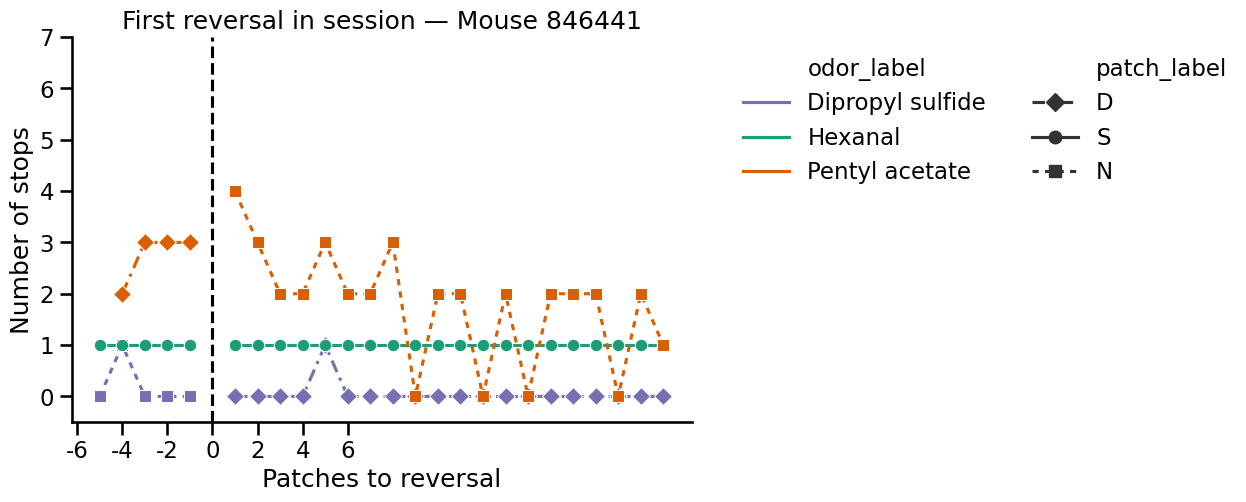

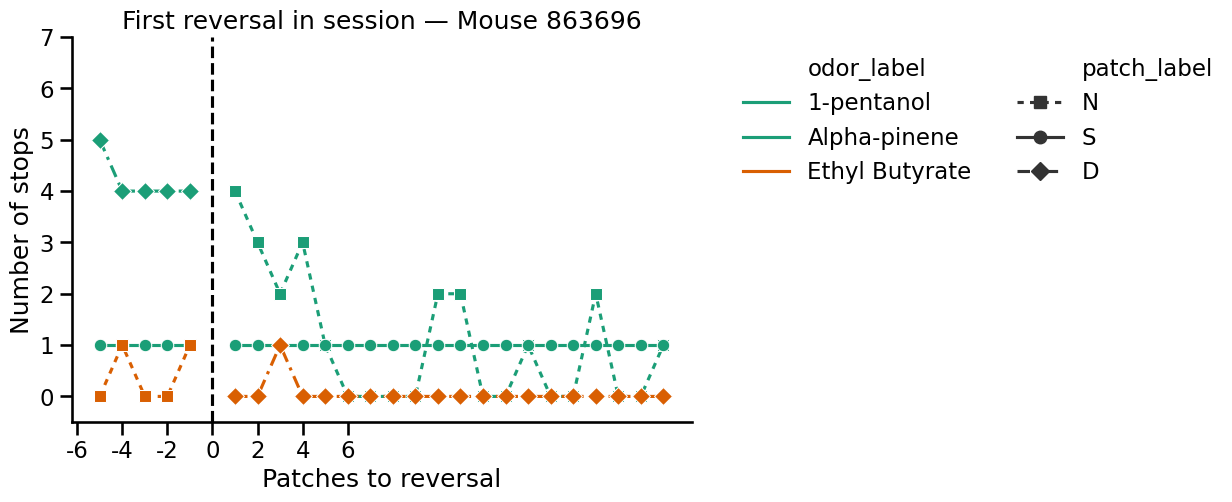

In [ ]:
mice = plot["mouse"].unique()
dash = {
    "S": "",        # solid
    "N": (2, 2),    # dashed
    "D": (4, 2, 1, 2),  # dash-dot
}
mark = {
    "S": "o",        # solid
    "N": "s",    # dashed
    "D": "D",  # dash-dot
}
for mouse in mice:
    fig, ax = plt.subplots(figsize=(8, 5))

    # forward
    sns.lineplot(
        data=plot.query("mouse == @mouse"),
        x="patch_align",
        y="is_choice",
        hue="odor_label",
        style="patch_label",
        palette=color_dict_label,
        dashes=dash,
        markers=mark,
        ax=ax
    )

    # reversal
    sns.lineplot(
        data=plot_r.query("mouse == @mouse"),
        x="patch_align_r",
        y="is_choice",
        hue="odor_label",
        style="patch_label",
        palette=color_dict_label,
        dashes=dash,
        markers=mark,
        ax=ax,
        legend=False
    )

    sns.despine()
    ax.set_ylim(-0.5, 7)
    ax.set_ylabel("Number of stops")
    ax.set_xlabel("Patches to reversal")
    ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
    ax.set_xticklabels([-6, -4, -2, 0, 2, 4, 6])
    ax.axvline(0, color="black", linestyle="--")

    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2, frameon=False)
    ax.set_title(f"First reversal in session — Mouse {mouse}")

    plt.show()

### Separated per patch type

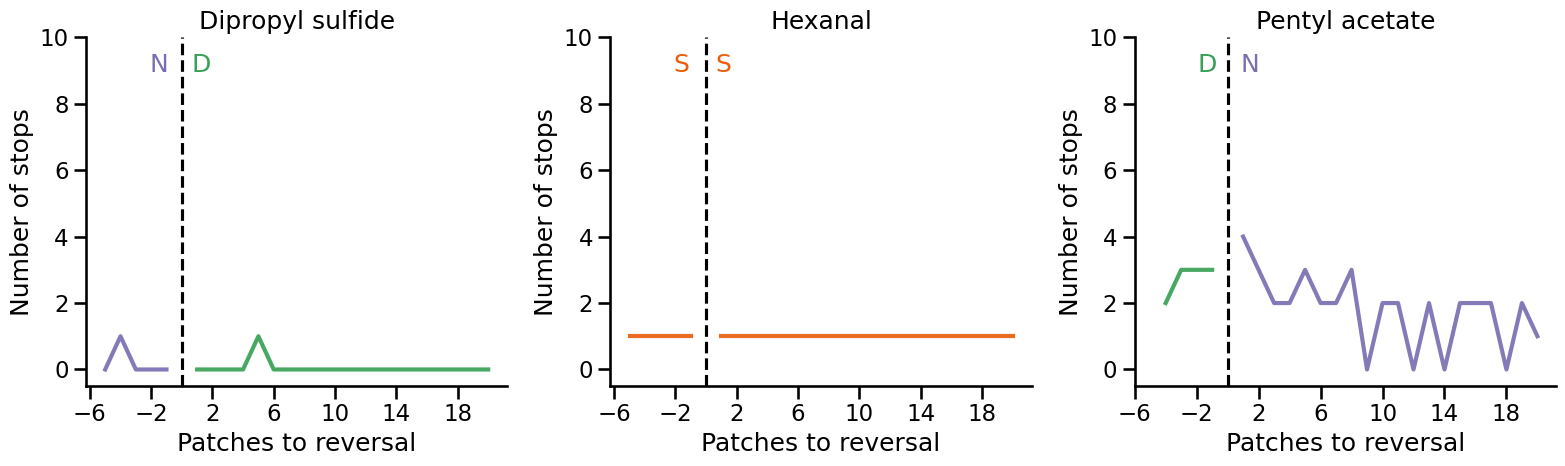

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tiffany.ona\\OneDrive - Allen Institute\\Documents\\VR foraging\\experiments\\batch 8 - learning\\results\\all_mice_deterministic_set1_reversal_set4_single_reversal_reduced_by_odor.pdf'

<Figure size 640x480 with 0 Axes>

In [ ]:
odor_labels = plot["odor_label"].unique()
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}

# one light tone (for individual) and one darker tone (for mean)
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for odor, ax in zip(odor_labels, axes.flatten()):
    patch_label_fwd = plot.loc[plot["odor_label"] == odor, "patch_label"].iloc[0]
    patch_label_rev = plot_r.loc[plot_r["odor_label"] == odor, "patch_label"].iloc[0]

    # individual traces (low alpha)
    sns.lineplot(
        data=plot.query("odor_label == @odor"),
        x="patch_align",
        y="is_choice",
        hue="mouse",
        palette=[patch_colors_light[patch_label_fwd]],
        alpha=0.4,
        linewidth=2,
        legend=False,
        errorbar=None,
        ax=ax
    )
    sns.lineplot(
        data=plot_r.query("odor_label == @odor"),
        x="patch_align_r",
        y="is_choice",
        hue="mouse",
        palette=[patch_colors_light[patch_label_rev]],
        alpha=0.4,
        linewidth=2,
        legend=False,
        errorbar=None,
        ax=ax
    )

    # mean traces (bolder color, higher alpha)
    mean_forward = (
        plot.query("odor_label == @odor")
        .groupby(["patch_align"], as_index=False)["is_choice"].mean()
    )
    mean_reverse = (
        plot_r.query("odor_label == @odor")
        .groupby(["patch_align_r"], as_index=False)["is_choice"].mean()
        .rename(columns={"patch_align_r": "patch_align"})
    )

    sns.lineplot(
        data=mean_forward,
        x="patch_align",
        y="is_choice",
        linewidth=3,
        color=patch_colors_bold[patch_label_fwd],
        alpha=0.9,
        ax=ax,
    )
    sns.lineplot(
        data=mean_reverse,
        x="patch_align",
        y="is_choice",
        linewidth=3,
        color=patch_colors_bold[patch_label_rev],
        alpha=0.9,
        ax=ax,
    )

    sns.despine()
    ax.text(0.25, 0.9, patch_label_fwd, transform=ax.transAxes, color=patch_colors_bold[patch_label_fwd])
    ax.text(0.15, 0.9, patch_label_rev, transform=ax.transAxes, color=patch_colors_bold[patch_label_rev])
    ax.axvline(0, color="black", linestyle="--")
    ax.set_ylim(-0.5, 10)
    ax.set_ylabel("Number of stops")
    ax.set_title(odor)
    ax.set_xlabel("Patches to reversal")
    ax.set_xticks(np.arange(-6, 22, 4))

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_path, f"all_mice_{stage[0]}_by_odor.pdf"))


### All collapsed

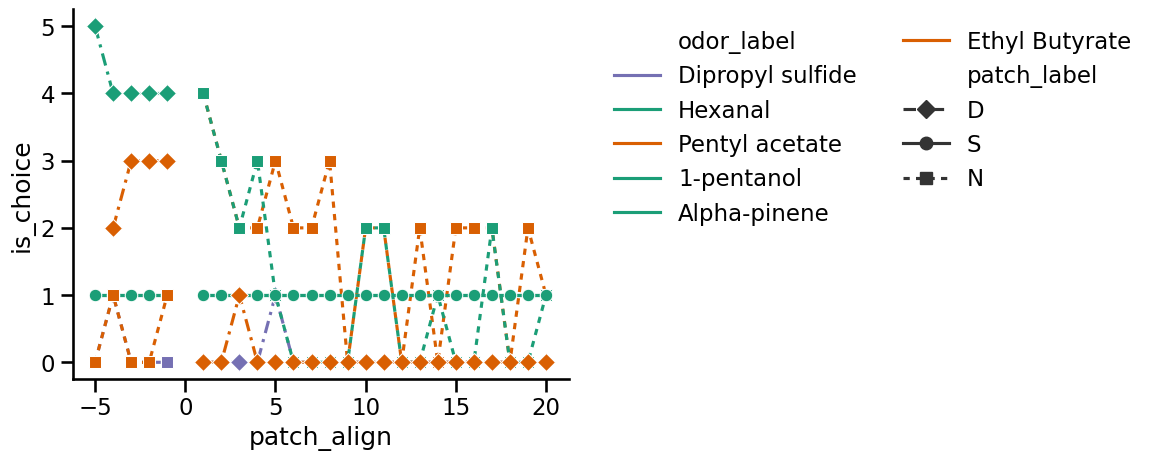

In [ ]:
dash = {
    "S": "",        # solid
    "N": (2, 2),    # dashed
    "D": (4, 2, 1, 2),  # dash-dot
}
sns.lineplot(
    data=plot,
    x="patch_align",
    y="is_choice",
    hue="odor_label",
    style="patch_label",
    palette=color_dict_label,
    dashes=dash,
    markers=mark,
    ci='sd'
)

sns.lineplot(
    data=plot_r,
    x="patch_align_r",
    y="is_choice",
    hue="odor_label",
    style="patch_label",
    palette=color_dict_label,
    dashes=dash,
    markers=mark,
    legend=False,
    ci='sd'
)

sns.despine()
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2, frameon=False)

### Stops before and after for multiple reversals

In [ ]:
summary_df['repeat'] = summary_df['stage'].str.contains('repeat').astype(int)

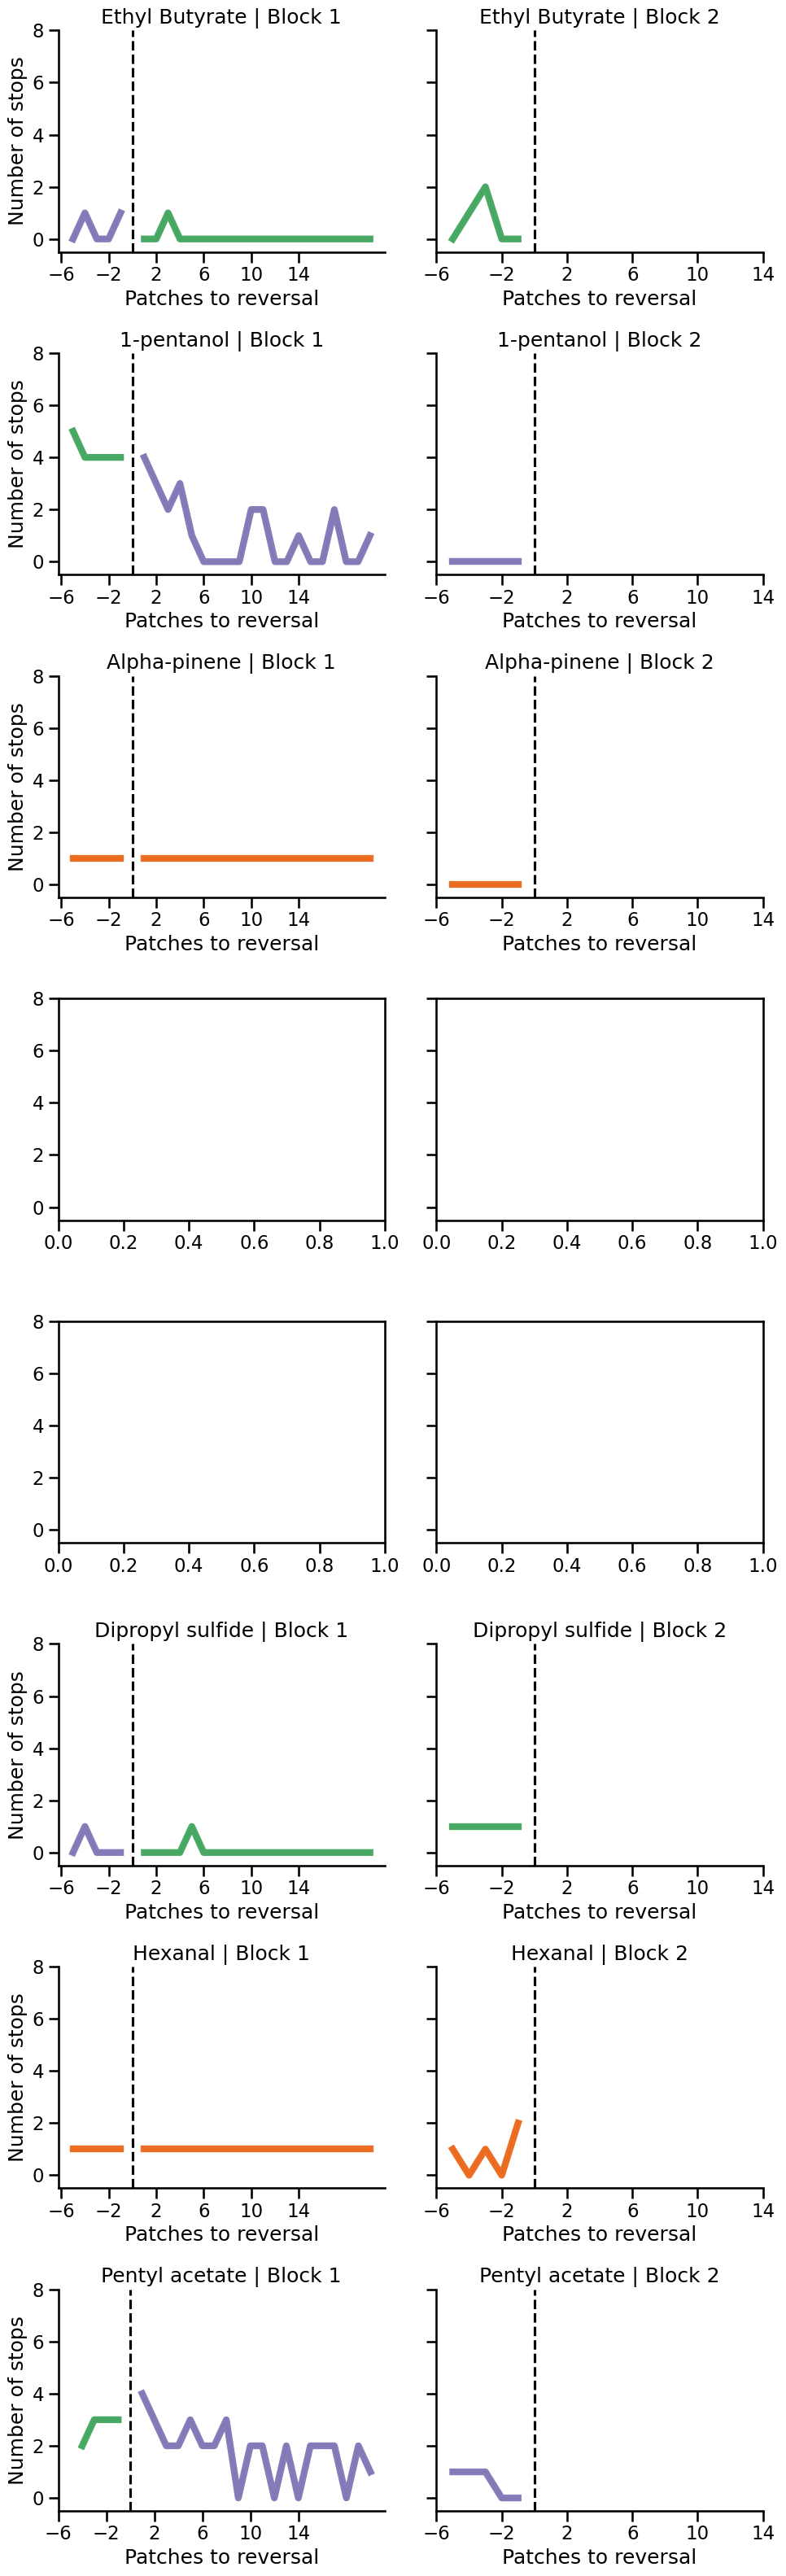

In [ ]:
# Parameters
# stage = [ 'learning_task3_set3_reversal_set0_repeat2']
block_range = sorted(summary_df['block_count'].unique()+1) # or choose subset
odor_labels = summary_df['odor_label'].unique()
selected_mice = None       # e.g., ['M1', 'M2'], or None for all
selected_sessions = None   # e.g., ['S1'], or None for all

# Filter summary_df
df = summary_df.loc[summary_df['stage'].isin(stage)]
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# Prepare colors
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

# Create figure grid: rows = odors, cols = block_count
fig, axes = plt.subplots(len(odor_labels), len(block_range), figsize=(5*len(block_range), 4*len(odor_labels)), sharey=True)

for i, odor in enumerate(odor_labels):
    for j, block_align in enumerate(block_range):
        ax = axes[i, j] if len(odor_labels) > 1 and len(block_range) > 1 else axes[max(i,j)]
        
        # forward window
        plot = df.loc[
            (df['block_count'] == block_align) & 
            (df['patch_align'] <= 20) & 
            (df['odor_label'] == odor)
        ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice':'sum'}).reset_index()
        
        # reverse window
        plot_r = df.loc[
            (df['block_count'] == block_align-1) &
            (df['patch_align_r'] >= -5) &
            (df['odor_label'] == odor)
        ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice':'sum'}).reset_index()
        
        if plot.empty and plot_r.empty:
            continue
        
        # Identify patch labels (for colors)
        patch_label_fwd = plot['patch_label'].iloc[0] if not plot.empty else None
        patch_label_rev = plot_r['patch_label'].iloc[0] if not plot_r.empty else None

        # Plot individual traces
        if not plot.empty:
            sns.lineplot(
                data=plot,
                x='patch_align',
                y='is_choice',
                hue='mouse',
                palette=[patch_colors_light[patch_label_fwd]],
                alpha=0.6,
                linewidth=2,
                legend=False,
                errorbar=None,
                ax=ax
            )
        if not plot_r.empty:
            sns.lineplot(
                data=plot_r,
                x='patch_align_r',
                y='is_choice',
                hue='mouse',
                palette=[patch_colors_light[patch_label_rev]],
                alpha=0.6,
                linewidth=2,
                legend=False,
                errorbar=None,
                ax=ax
            )
        
        # Plot mean traces
        if not plot.empty:
            mean_forward = plot.groupby('patch_align', as_index=False)['is_choice'].mean()
            sns.lineplot(
                data=mean_forward,
                x='patch_align',
                y='is_choice',
                linewidth=6,
                color=patch_colors_bold[patch_label_fwd],
                alpha=0.9,
                ax=ax
            )
        if not plot_r.empty:
            mean_reverse = plot_r.groupby('patch_align_r', as_index=False)['is_choice'].mean().rename(columns={'patch_align_r':'patch_align'})
            sns.lineplot(
                data=mean_reverse,
                x='patch_align',
                y='is_choice',
                linewidth=6,
                color=patch_colors_bold[patch_label_rev],
                alpha=0.9,
                ax=ax
            )
        
        # Decorations
        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{odor} | Block {block_align-1}')
        ax.set_xlabel('Patches to reversal')
        ax.set_ylabel('Number of stops')
        ax.set_ylim(-0.5, 8)
        ax.set_xticks(np.arange(-6, 18, 4))
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(results_path, f"all_mice_{stage[0]}_grid.pdf"))


In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
selected_mice       = None
selected_sessions   = None
selected_transition = ('N', 'D')
plot_mode           = 'difference'  # 'stops' or 'difference'
# ──────────────────────────────────────────────────────────────────────────────

# ── Filter ────────────────────────────────────────────────────────────────────
df = summary_df.loc[summary_df.repeat == 1].copy()
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# ── Filter to sessions containing the transition ──────────────────────────────
if selected_transition is not None:
    label_before, label_after = selected_transition

    block_labels = (
        df.groupby(['mouse', 'session', 'block_count', 'odor_label', 'patch_label'])
        .size().reset_index(name='count')
        .sort_values('count', ascending=False)
        .groupby(['mouse', 'session', 'block_count', 'odor_label']).first()
        .reset_index()[['mouse', 'session', 'block_count', 'odor_label', 'patch_label']]
    )

    merged = block_labels.merge(
        block_labels.rename(columns={
            'block_count': 'next_block',
            'patch_label': 'next_label',
            'odor_label':  'next_odor'
        }),
        on=['mouse', 'session']
    )
    merged = merged[
        (merged['next_block'] == merged['block_count'] + 1) &
        (merged['patch_label'] == label_before) &
        (merged['next_label'] == label_after) &
        (merged['odor_label'] == merged['next_odor'])
    ]

    transitioning_odors = merged[['mouse', 'session', 'odor_label']].drop_duplicates()
    valid_sessions      = transitioning_odors[['mouse', 'session']].drop_duplicates()

    print(f"Sessions with ({label_before}→{label_after}): {len(valid_sessions)}")
    df = df.merge(valid_sessions, on=['mouse', 'session'], how='inner')

# ── Behavioral anchor ─────────────────────────────────────────────────────────
def find_behavioral_anchor_post_reversal(group):
    group = group[group['patch_align'] >= 0].sort_values('patch_align')
    seen_low = False
    for _, row in group.iterrows():
        if row['is_choice'] < 2:
            seen_low = True
        if seen_low and row['is_choice'] >= 4:
            return row['patch_align']
    return np.nan

choice_per_patch = (
    df.merge(transitioning_odors, on=['mouse', 'session', 'odor_label'], how='inner')
    .groupby(['mouse', 'session', 'block_count', 'odor_label', 'patch_align'])['is_choice']
    .sum().reset_index()
)

anchors = (
    choice_per_patch
    .groupby(['mouse', 'session', 'block_count', 'odor_label'])
    .apply(find_behavioral_anchor_post_reversal)
    .reset_index()
)
anchors.columns = [*anchors.columns[:-1], 'anchor_patch_align']
print(f"Anchors found: {anchors['anchor_patch_align'].notna().sum()} / {len(anchors)}")

# ── Build a flat pooled dataframe: one row per (mouse, session, odor, block, x) ──
# Each (session, odor) is an independent "trial" aligned to its own anchor
all_traces = []
for (mouse, session, odor), grp in anchors.groupby(['mouse', 'session', 'odor_label']):
    for _, row in grp.iterrows():
        if pd.isna(row['anchor_patch_align']):
            continue
        block   = row['block_count']
        anchor  = row['anchor_patch_align']

        # Get the raw data for this (session, odor, block)
        raw = df.loc[
            (df['mouse'] == mouse) &
            (df['session'] == session) &
            (df['block_count'] == block) &
            (df['odor_label'] == odor)
        ].groupby(['patch_label', 'patch_align'])['is_choice'].sum().reset_index()

        if raw.empty:
            continue

        raw['patch_align_beh'] = raw['patch_align'] - anchor
        raw['mouse']           = mouse
        raw['session']         = session
        raw['odor_label']      = odor
        raw['block_count']     = block
        all_traces.append(raw)

pooled = pd.concat(all_traces, ignore_index=True)

# ── Assign session order per mouse ───────────────────────────────────────────
session_order = (
    pooled[['mouse', 'session']].drop_duplicates()
    .sort_values(['mouse', 'session'])
    .groupby('mouse', group_keys=False)
    .apply(lambda g: g.assign(session_idx=range(1, len(g) + 1)))
)
pooled = pooled.merge(session_order, on=['mouse', 'session'], how='left')

# ── Colors & thresholds ───────────────────────────────────────────────────────
patch_thresholds  = {'D': 4, 'S': 1, 'N': 0}
patch_palettes    = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_bold = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

def compute_y(data, mode):
    data = data.copy()
    if mode == 'difference':
        data['y'] = data.apply(
            lambda r: r['is_choice'] - patch_thresholds.get(r['patch_label'], 0), axis=1
        )
    else:
        data['y'] = data['is_choice']
    return data

ylabel = 'Stops − optimal threshold' if plot_mode == 'difference' else 'Number of stops'
ylims  = (-5, 5) if plot_mode == 'difference' else (-0.5, 6)

# ── Plot: one figure per mouse ────────────────────────────────────────────────
for stage in df['stage'].unique():
    pooled_stage = pooled[pooled['mouse'].isin(df[df['stage'] == stage]['mouse'].unique())]

    for mouse in pooled_stage['mouse'].unique():
        pooled_mouse = pooled_stage[pooled_stage['mouse'] == mouse]

        sessions   = sorted(pooled_mouse['session'].unique())
        n_sessions = len(sessions)

        cmap = plt.cm.magma
        session_colors = {
            s: cmap(0.1 + 0.85 * (i) / max(n_sessions - 1, 1))
            for i, s in enumerate(sessions)
        }

        fig, ax = plt.subplots(figsize=(6, 4.5))

        for session in sessions:
            pooled_session = pooled_mouse[pooled_mouse['session'] == session]
            color          = session_colors[session]
            sidx           = pooled_session['session_idx'].iloc[0]

            # Individual block+odor traces (faint)
            # for (block, odor), grp in pooled_session.groupby(['block_count', 'odor_label']):
            #     trace = grp.loc[
            #         (grp['patch_align_beh'] >= -10) &
            #         (grp['patch_align_beh'] <= 10)
            #     ].copy()
            #     if trace.empty:
            #         continue
            #     trace = compute_y(trace, plot_mode)
            #     ax.plot(
            #         trace['patch_align_beh'], trace['y'],
            #         color=color, linewidth=0.8, alpha=0.15, marker='', zorder=1
            #     )

            # Session mean (bold) — averaged across all blocks + odors
            session_mean = (
                pooled_session.loc[
                    (pooled_session['patch_align_beh'] >= -10) &
                    (pooled_session['patch_align_beh'] <= 10)
                ]
                .pipe(lambda d: compute_y(d, plot_mode))
                .groupby('patch_align_beh')['y'].mean()
                .reset_index()
            )
            ax.plot(
                session_mean['patch_align_beh'], session_mean['y'],
                color=color, linewidth=2.5, alpha=0.9,
                marker='', zorder=2, label=f'Session {sidx}'
            )

        # Threshold lines
        for idx, label_ in enumerate(selected_transition):
            xmin, xmax = (-10, 0) if idx == 0 else (0, 10)
            thresh_y   = 0 if plot_mode == 'difference' else patch_thresholds[label_]
            ax.hlines(
                thresh_y, xmin=xmin, xmax=xmax,
                color='black', linestyle='--', linewidth=1, alpha=0.4
            )

        # Colorbar
        sm = plt.cm.ScalarMappable(
            cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n_sessions)
        )
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label('Session', fontsize=10)
        cbar.set_ticks(range(1, n_sessions + 1))
        cbar.outline.set_visible(False)

        ax.axvline(0, color='k', linestyle='--', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        ax.axvspan(-10, 0, color='gray', alpha=0.04)
        ax.set_xlabel('Patches from behavioral change', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(*ylims)
        ax.set_xticks(np.arange(-10, 11, 5))
        ax.set_xlim(-10, 11)
        sns.despine(ax=ax)

        plt.suptitle(
            f'Mouse {mouse} | Stage: {stage}\n'
            f'{label_before}→{label_after} | {plot_mode} | all odors pooled',
            fontsize=11
        )
        plt.tight_layout()
        plt.savefig(os.path.join(
            results_path,
            f"mouse_{mouse}_stage_{stage}_beh_aligned_{plot_mode}_pooled.pdf"
        ))
        # plt.close(fig)

Sessions with (N→D): 0


C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_36160\3370694269.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(find_behavioral_anchor_post_reversal)


ValueError: cannot insert odor_label, already exists

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
selected_mice       = None
selected_sessions   = None
selected_transition = ('N', 'D')
plot_mode           = 'difference'  # 'stops' or 'difference'
# ──────────────────────────────────────────────────────────────────────────────

In [ ]:

# ── Filter ────────────────────────────────────────────────────────────────────
# df = summary_df.loc[summary_df.repeat == 1].copy()
df = summary_df
# .loc[summary_df['mouse'] = 789917]

if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# ── Filter to sessions containing the transition ──────────────────────────────
if selected_transition is not None:
    label_before, label_after = selected_transition

    block_labels = (
        df.groupby(['mouse', 'session', 'block_count', 'odor_label', 'patch_label'])
        .size().reset_index(name='count')
        .sort_values('count', ascending=False)
        .groupby(['mouse', 'session', 'block_count', 'odor_label']).first()
        .reset_index()[['mouse', 'session', 'block_count', 'odor_label', 'patch_label']]
    )

    merged = block_labels.merge(
        block_labels.rename(columns={
            'block_count': 'next_block',
            'patch_label': 'next_label',
            'odor_label':  'next_odor'
        }),
        on=['mouse', 'session']
    )
    merged = merged[
        (merged['next_block'] == merged['block_count'] + 1) &
        (merged['patch_label'] == label_before) &
        (merged['next_label'] == label_after) &
        (merged['odor_label'] == merged['next_odor'])
    ]

    transitioning_odors = merged[['mouse', 'session', 'odor_label']].drop_duplicates()
    valid_sessions      = transitioning_odors[['mouse', 'session']].drop_duplicates()

    print(f"Sessions with ({label_before}→{label_after}): {len(valid_sessions)}")

    df = df.merge(valid_sessions, on=['mouse', 'session'], how='inner')

# ── Behavioral anchor ─────────────────────────────────────────────────────────
def find_behavioral_anchor_post_reversal(group):
    group = group[group['patch_align'] >= 0].sort_values('patch_align')
    
    # Find all patches with is_choice >= 4
    high_patches = group[group['is_choice'] >= 5]
    if high_patches.empty:
        return np.nan
    
    for _, high_row in high_patches.iterrows():
        # Look for a low patch (<2) that comes BEFORE this high patch
        low_before = group[
            (group['is_choice'] < 3) &
            (group['patch_align'] < high_row['patch_align'])
        ]
        if low_before.empty:
            continue
        
        # Take the one closest to the high patch (largest patch_align < high)
        closest_low = low_before.iloc[-1]  # last one before high = closest to reversal
        
        # Check no other high patch sits between the closest low and this high
        between = group[
            (group['patch_align'] > closest_low['patch_align']) &
            (group['patch_align'] < high_row['patch_align']) &
            (group['is_choice'] >= 4)
        ]
        if between.empty:
            return high_row['patch_align']
    
    return np.nan

choice_per_patch = (
    df.merge(transitioning_odors, on=['mouse', 'session', 'odor_label'], how='inner')
    .groupby(['mouse', 'session', 'block_count', 'odor_label', 'patch_align'])['is_choice']
    .sum().reset_index()
)

anchors = (
    choice_per_patch
    .groupby(['mouse', 'session', 'block_count', 'odor_label'])
    .apply(find_behavioral_anchor_post_reversal)
    .reset_index()
)
anchors.columns = [*anchors.columns[:-1], 'anchor_patch_align']
print(f"Anchors found: {anchors['anchor_patch_align'].notna().sum()} / {len(anchors)}")


# ── Build pooled dataframe ────────────────────────────────────────────────────
all_traces = []
for (mouse, session, odor), grp in anchors.groupby(['mouse', 'session', 'odor_label']):
    for _, row in grp.iterrows():
        if pd.isna(row['anchor_patch_align']):
            continue
        block  = row['block_count']
        anchor = row['anchor_patch_align']

        raw = df.loc[
            (df['mouse'] == mouse) &
            (df['session'] == session) &
            (df['block_count'] == block) &
            (df['odor_label'] == odor)
        ].groupby(['patch_label', 'patch_align'])['is_choice'].sum().reset_index()

        if raw.empty:
            continue

        raw['patch_align_beh'] = raw['patch_align'] - anchor
        raw['mouse']           = mouse
        raw['session']         = session
        raw['odor_label']      = odor
        raw['block_count']     = block
        all_traces.append(raw)

pooled = pd.concat(all_traces, ignore_index=True)

# ── Assign session order per mouse ───────────────────────────────────────────
session_order = (
    pooled[['mouse', 'session']].drop_duplicates()
    .sort_values(['mouse', 'session'])
)
session_order['session_idx'] = session_order.groupby('mouse').cumcount() + 1
pooled = pooled.merge(session_order, on=['mouse', 'session'], how='left')

print(f"Sessions in pooled: {pooled['session'].nunique()}")
print(f"Max session idx: {pooled['session_idx'].max()}")
pooled = pooled.loc[(pooled.mouse != 789925) & (pooled.mouse != 789923)]  

# ── Colors & thresholds ───────────────────────────────────────────────────────
patch_thresholds  = {'D': 4, 'S': 1, 'N': 0}
patch_palettes    = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_bold = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

def compute_y(data, mode):
    data = data.copy()
    if mode == 'difference':
        data['y'] = data.apply(
            lambda r: r['is_choice'] - patch_thresholds.get(r['patch_label'], 0), axis=1
        )
    else:
        data['y'] = data['is_choice']
    return data

ylabel = 'Stops − optimal threshold' if plot_mode == 'difference' else 'Number of stops'
ylims  = (-5, 5) if plot_mode == 'difference' else (-0.5, 6)

# ── One plot total ────────────────────────────────────────────────────────────
max_session    = pooled['session_idx'].max()
cmap           = plt.cm.magma_r
session_colors = {
    s: cmap(0.1 + 0.7 * (s - 1) / max(max_session - 1, 1))  # 0.1 → 0.65 stays in purple-orange range
    for s in range(1, max_session + 1)
}

fig, ax = plt.subplots(figsize=(6, 4.5))
pooled.loc[(pooled.session_idx == 13)&(pooled.patch_align_beh == 0), 'is_choice'] -= .5
pooled.loc[(pooled.session_idx == 2)&(pooled.patch_align_beh >= 0), 'is_choice'] += 0.5

for session_idx in range(1, max_session + 1):
    if session_idx in [2, 9, 13]:
        alpha = 1
        linewidth = 3
    else:
        alpha = 0.5
        linewidth = 1.5
        
        
    pooled_sess = pooled[
        (pooled['session_idx'] == session_idx) &
        (pooled['patch_align_beh'] >= -20) &
        (pooled['patch_align_beh'] <= 10)
    ].copy()

    if pooled_sess.empty:
        continue

    pooled_sess = compute_y(pooled_sess, plot_mode)
    color       = session_colors[session_idx]

    # Individual mouse traces (faint) — mean per mouse across blocks + odors
    # for mouse, mouse_grp in pooled_sess.groupby('mouse'):
    #     mouse_mean = mouse_grp.groupby('patch_align_beh')['y'].mean().reset_index()
    #     ax.plot(
    #         mouse_mean['patch_align_beh'], mouse_mean['y'],
    #         color=color, linewidth=0.8, alpha=0.2, marker='', zorder=1
    #     )

    # Grand mean across all mice
    # grand_mean = pooled_sess.groupby('patch_align_beh')['y'].mean().reset_index()
    # ax.plot(
    #     grand_mean['patch_align_beh'], grand_mean['y'],
    #     color=color, linewidth=2.5, alpha=0.9,
    #     marker='', zorder=2, label=f'Session {session_idx}'
    # )

    # Grand mean ± SEM across all mice
    mouse_means = (
        pooled_sess
        .groupby(['mouse', 'patch_align_beh'])['y']
        .mean()
        .reset_index()
    )
    grand = (
        mouse_means
        .groupby('patch_align_beh')['y']
        .agg(['mean', 'sem'])
        .reset_index()
    )

    ax.plot(
        grand['patch_align_beh'], grand['mean'],
        color=color, linewidth=linewidth, alpha=alpha,
        marker='', zorder=2, label=f'Session {session_idx}'
    )
    
    if session_idx in [2, 9, 13]:
        ax.plot(
            grand['patch_align_beh'].iloc[0], grand['mean'].iloc[0],
            color=color, linewidth=linewidth, alpha=alpha,
            marker='o', zorder=2, label=f'Session {session_idx}'
        )
    # ax.fill_between(
    #     grand['patch_align_beh'],
    #     grand['mean'] - grand['sem'],
    #     grand['mean'] + grand['sem'],
    #     color=color, alpha=0.15, zorder=1, linewidth=0
    # )
# Threshold lines
for idx, label_ in enumerate(selected_transition):
    xmin, xmax = (-20, 0) if idx == 0 else (0, 10)
    thresh_y   = 0 if plot_mode == 'difference' else patch_thresholds[label_]
    ax.hlines(
        thresh_y, xmin=xmin, xmax=xmax,
        color='black', linestyle='--', linewidth=1, alpha=0.4
    )

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max_session))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Session number', fontsize=10)
cbar.set_ticks(range(2, max_session + 1, 2))
cbar.outline.set_visible(False)

ax.axvline(0, color='k', linestyle='--', linewidth=1.5)
# ax.axvspan(-10, 0, color='gray', alpha=0.04)
ax.set_xlabel('Patches from behavioral change', fontsize=12)
ax.set_ylabel(ylabel, fontsize=12)
ax.set_ylim(*ylims)
ax.set_xticks(np.arange(-20, 11, 5))
ax.set_xlim(-21, 11)
sns.despine(ax=ax)

plt.suptitle(
    f'All mice | {label_before}→{label_after} | {plot_mode} ',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(
    results_path,
    f"all_mice_beh_aligned_{plot_mode}_pooled.svg"
))
# plt.close(fig)

## Only one stage, lines are mice.

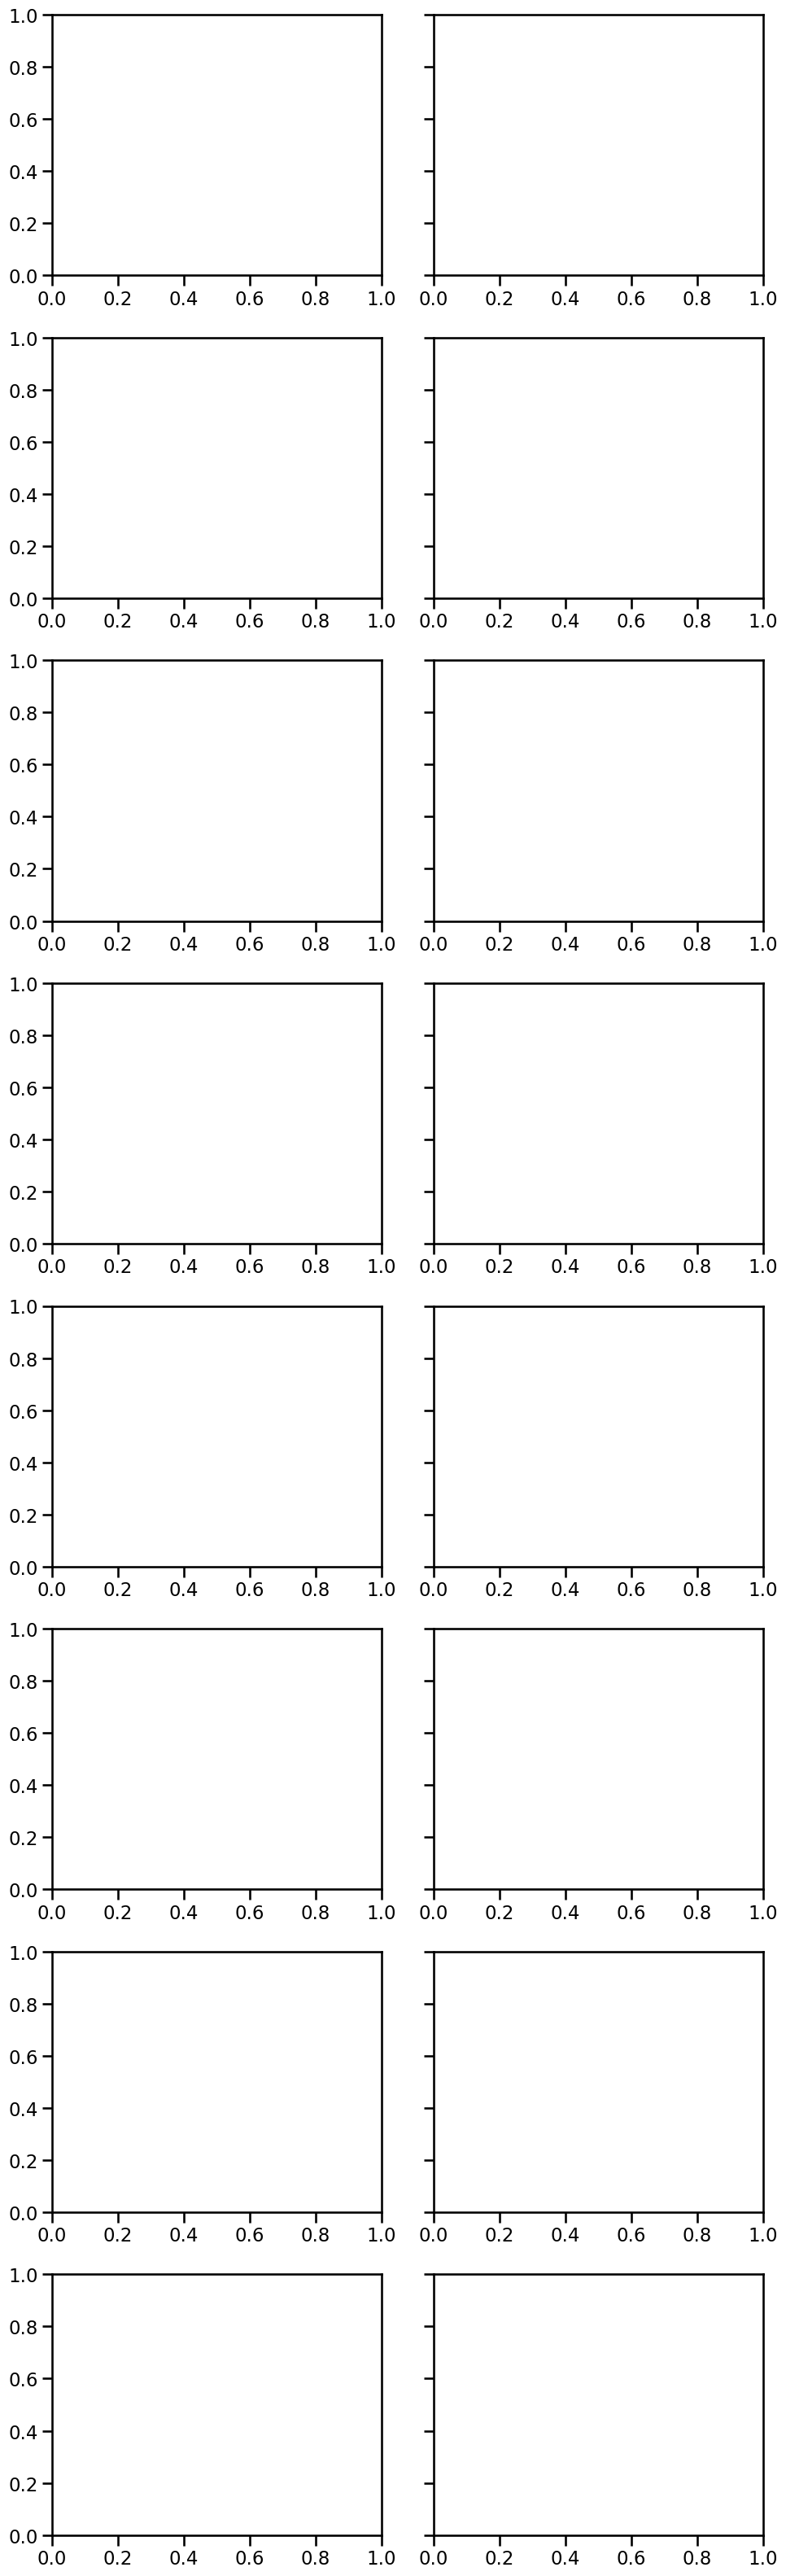

FileNotFoundError: [Errno 2] No such file or directory: "C:\\Users\\tiffany.ona\\OneDrive - Allen Institute\\Documents\\VR foraging\\experiments\\batch 8 - learning\\results\\all_mice_['learning_task3_set0_reversal_set3_repeat1']_grid.pdf"

<Figure size 640x480 with 0 Axes>

In [ ]:
# Parameters
stage = [ 'learning_task3_set0_reversal_set3_repeat1']
block_range = sorted(summary_df['block_count'].unique()+1) # or choose subset
odor_labels = summary_df['odor_label'].unique()
selected_mice = None       # e.g., ['M1', 'M2'], or None for all
selected_sessions = None   # e.g., ['S1'], or None for all

# Filter summary_df
df = summary_df.loc[summary_df['stage'].isin(stage)]
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# Prepare colors
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

# Create figure grid: rows = odors, cols = block_count
fig, axes = plt.subplots(len(odor_labels), len(block_range), figsize=(5*len(block_range), 4*len(odor_labels)), sharey=True)

for i, odor in enumerate(odor_labels):
    for j, block_align in enumerate(block_range):
        ax = axes[i, j] if len(odor_labels) > 1 and len(block_range) > 1 else axes[max(i,j)]
        
        # forward window
        plot = df.loc[
            (df['block_count'] == block_align) & 
            (df['patch_align'] <= 20) & 
            (df['odor_label'] == odor)
        ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice':'sum'}).reset_index()
        
        # reverse window
        plot_r = df.loc[
            (df['block_count'] == block_align-1) &
            (df['patch_align_r'] >= -5) &
            (df['odor_label'] == odor)
        ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice':'sum'}).reset_index()
        
        if plot.empty and plot_r.empty:
            continue
        
        # Identify patch labels (for colors)
        patch_label_fwd = plot['patch_label'].iloc[0] if not plot.empty else None
        patch_label_rev = plot_r['patch_label'].iloc[0] if not plot_r.empty else None

        # Plot individual traces
        if not plot.empty:
            sns.lineplot(
                data=plot,
                x='patch_align',
                y='is_choice',
                hue='mouse',
                palette=[patch_colors_light[patch_label_fwd]],
                alpha=0.6,
                linewidth=2,
                legend=False,
                errorbar=None,
                ax=ax
            )
        if not plot_r.empty:
            sns.lineplot(
                data=plot_r,
                x='patch_align_r',
                y='is_choice',
                hue='mouse',
                palette=[patch_colors_light[patch_label_rev]],
                alpha=0.6,
                linewidth=2,
                legend=False,
                errorbar=None,
                ax=ax
            )
        
        # Plot mean traces
        if not plot.empty:
            mean_forward = plot.groupby('patch_align', as_index=False)['is_choice'].mean()
            sns.lineplot(
                data=mean_forward,
                x='patch_align',
                y='is_choice',
                linewidth=6,
                color=patch_colors_bold[patch_label_fwd],
                alpha=0.9,
                ax=ax
            )
        if not plot_r.empty:
            mean_reverse = plot_r.groupby('patch_align_r', as_index=False)['is_choice'].mean().rename(columns={'patch_align_r':'patch_align'})
            sns.lineplot(
                data=mean_reverse,
                x='patch_align',
                y='is_choice',
                linewidth=6,
                color=patch_colors_bold[patch_label_rev],
                alpha=0.9,
                ax=ax
            )
        
        # Decorations
        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{odor} | Block {block_align-1}')
        ax.set_xlabel('Patches to reversal')
        ax.set_ylabel('Number of stops')
        ax.set_ylim(-0.5, 8)
        ax.set_xticks(np.arange(-6, 18, 4))
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(results_path, f"all_mice_{stage}_grid.pdf"))


## One page per mouse and session

In [ ]:
plot.groupby('patch_align', as_index=False)['is_choice'].mean()

,patch_align,is_choice
0,1.0,1.666667
1,2.0,1.333333
2,3.0,1.166667
3,4.0,1.166667
4,5.0,1.166667
5,6.0,0.666667
6,7.0,0.666667
7,8.0,0.833333
8,9.0,0.333333
9,10.0,1.0


In [ ]:
# Parameters
block_range = sorted(summary_df['block_count'].unique()+1) # or choose subset
odor_labels = summary_df['odor_label'].unique()
selected_mice = None       # e.g., ['M1', 'M2'], or None for all
selected_sessions = None   # e.g., ['S1'], or None for all

# Add this with the other color dicts at the top
patch_thresholds = {'D': 4, 'S': 1, 'N': 0}  # ← adjust values as needed

# Filter summary_df
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# Prepare colors
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

for stage in df['stage'].unique():
    df_stage = df.loc[df['stage'] == stage]
    for mouse in df_stage['mouse'].unique():
        df_mouse = df_stage.loc[df_stage['mouse'] == mouse]
        for session in df_mouse['session'].unique():
            df_session = df_mouse.loc[df_mouse['session'] == session]
            # Create figure grid: rows = odors, cols = block_count
            fig, axes = plt.subplots(len(odor_labels), len(block_range), figsize=(3*len(block_range), 3.5*len(odor_labels)), sharey=True)

            for i, odor in enumerate(odor_labels):
                for j, block_align in enumerate(block_range):
                    ax = axes[i, j] if len(odor_labels) > 1 and len(block_range) > 1 else axes[max(i,j)]
                    
                    # forward window
                    plot = df_session.loc[
                        (df_session['block_count'] == block_align) & 
                        (df_session['patch_align'] <= 10) & 
                        (df_session['odor_label'] == odor)
                    ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice':'sum'}).reset_index()
                    
                    # reverse window
                    plot_r = df_session.loc[
                        (df_session['block_count'] == block_align-1) &
                        (df_session['patch_align_r'] >= -5) &
                        (df_session['odor_label'] == odor)
                    ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice':'sum'}).reset_index()
                    
                    if plot.empty and plot_r.empty:
                        continue
                    
                    # Identify patch labels (for colors)
                    patch_label_fwd = plot['patch_label'].iloc[0] if not plot.empty else None
                    patch_label_rev = plot_r['patch_label'].iloc[0] if not plot_r.empty else None

                    # # Plot individual traces
                    # if not plot.empty:
                    #     sns.lineplot(
                    #         data=plot,
                    #         x='patch_align',
                    #         y='is_choice',
                    #         hue='session',
                    #         palette=[patch_colors_light[patch_label_fwd]],
                    #         alpha=0.6,
                    #         linewidth=2,
                    #         legend=False,
                    #         zorder=100,
                    #         errorbar=None,
                    #         ax=ax
                    #     )
                    # if not plot_r.empty:
                    #     sns.lineplot(
                    #         data=plot_r,
                    #         x='patch_align_r',
                    #         y='is_choice',
                    #         hue='session',
                    #         palette=[patch_colors_light[patch_label_rev]],
                    #         alpha=0.6,
                    #         linewidth=2,
                    #         zorder=100,
                    #         legend=False,
                    #         errorbar=None,
                    #         ax=ax
                    #     )
                    
                    # Plot mean traces
                    if not plot.empty:
                        mean_forward = plot.groupby('patch_align', as_index=False)['is_choice'].mean()
                        sns.lineplot(
                            data=mean_forward,
                            x='patch_align',
                            y='is_choice',
                            linewidth=6,
                            zorder = 100,
                            color=patch_colors_bold[patch_label_fwd],
                            alpha=0.9,
                            ax=ax
                        )
                    if not plot_r.empty:
                        mean_reverse = plot_r.groupby('patch_align_r', as_index=False)['is_choice'].mean().rename(columns={'patch_align_r':'patch_align'})
                        sns.lineplot(
                            data=mean_reverse,
                            x='patch_align',
                            y='is_choice',
                            linewidth=6,
                            zorder = 100,
                            color=patch_colors_bold[patch_label_rev],
                            alpha=0.9,
                            ax=ax
                        )
                    
                    # Decorations
                    # ax.axvline(0, color='k', linestyle='--')
                    
                    # Horizontal threshold lines — fwd from 0 to end, rev from -5 to 0
                    if patch_label_fwd is not None:
                        ax.hlines(
                            patch_thresholds[patch_label_fwd],
                            xmin=0, xmax=10,
                            color='black', zorder=1,
                            linestyle='--', linewidth=2.5, alpha=0.7
                        )
                    if patch_label_rev is not None:
                        ax.hlines(
                            patch_thresholds[patch_label_rev],
                            xmin=-5, xmax=0,
                            color='black', zorder=1,
                            linestyle='--', linewidth=2.5, alpha=0.7
                        )
                    ax.set_title(f'Block {block_align-1}')
                    # ax.set_title(f'{odor} | Block {block_align-1}')
                    ax.set_xlabel('Patches to reversal')
                    ax.set_ylabel('Number of stops')
                    ax.set_ylim(-0.5, 6.5)
                    ax.set_yticks(np.arange(0, 7, 6))
                    ax.set_xticks(np.arange(-5, 15, 5))
                    ax.set_xlim(-6, 12)
                    sns.despine(ax=ax)
            
            plt.suptitle(f'Mouse {mouse} | Stage: {stage} | Session: {session}')
            plt.tight_layout()

            plt.savefig(os.path.join(results_path, f"mouse_{mouse}_stage_{stage}_session_{session}.pdf"))
            # plt.close(fig)



## All stages, one plot per mouse and lines are sessions

In [ ]:
# Parameters
block_range = sorted(summary_df['block_count'].unique()+1) # or choose subset
odor_labels = summary_df['odor_label'].unique()
selected_mice = None       # e.g., ['M1', 'M2'], or None for all
selected_sessions = None   # e.g., ['S1'], or None for all

# Filter summary_df
df = summary_df.loc[summary_df.repeat == 1]
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# Prepare colors
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

with PdfPages(os.path.join(results_path, f"all_mice_repeats_grid.pdf")) as pdf:
    for stage in df['stage'].unique():
        df_stage = df.loc[df['stage'] == stage]
        for mouse in df_stage['mouse'].unique():
            df_mouse = df_stage.loc[df_stage['mouse'] == mouse]
            # Create figure grid: rows = odors, cols = block_count
            fig, axes = plt.subplots(len(odor_labels), len(block_range), figsize=(5*len(block_range), 4.3*len(odor_labels)), sharey=True)

            for i, odor in enumerate(odor_labels):
                for j, block_align in enumerate(block_range):
                    ax = axes[i, j] if len(odor_labels) > 1 and len(block_range) > 1 else axes[max(i,j)]
                    
                    # forward window
                    plot = df_mouse.loc[
                        (df_mouse['block_count'] == block_align) & 
                        (df_mouse['patch_align'] <= 14) & 
                        (df_mouse['odor_label'] == odor)
                    ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice':'sum'}).reset_index()
                    
                    # reverse window
                    plot_r = df_mouse.loc[
                        (df_mouse['block_count'] == block_align-1) &
                        (df_mouse['patch_align_r'] >= -5) &
                        (df_mouse['odor_label'] == odor)
                    ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice':'sum'}).reset_index()
                    
                    if plot.empty and plot_r.empty:
                        continue
                    
                    # Identify patch labels (for colors)
                    patch_label_fwd = plot['patch_label'].iloc[0] if not plot.empty else None
                    patch_label_rev = plot_r['patch_label'].iloc[0] if not plot_r.empty else None

                    # Plot individual traces
                    if not plot.empty:
                        sns.lineplot(
                            data=plot,
                            x='patch_align',
                            y='is_choice',
                            hue='session',
                            palette=[patch_colors_light[patch_label_fwd]],
                            alpha=0.6,
                            linewidth=2,
                            legend=False,
                            errorbar=None,
                            ax=ax
                        )
                    if not plot_r.empty:
                        sns.lineplot(
                            data=plot_r,
                            x='patch_align_r',
                            y='is_choice',
                            hue='session',
                            palette=[patch_colors_light[patch_label_rev]],
                            alpha=0.6,
                            linewidth=2,
                            legend=False,
                            errorbar=None,
                            ax=ax
                        )
                    
                    # Plot mean traces
                    if not plot.empty:
                        mean_forward = plot.groupby('patch_align', as_index=False)['is_choice'].mean()
                        sns.lineplot(
                            data=mean_forward,
                            x='patch_align',
                            y='is_choice',
                            linewidth=6,
                            color=patch_colors_bold[patch_label_fwd],
                            alpha=0.9,
                            ax=ax
                        )
                    if not plot_r.empty:
                        mean_reverse = plot_r.groupby('patch_align_r', as_index=False)['is_choice'].mean().rename(columns={'patch_align_r':'patch_align'})
                        sns.lineplot(
                            data=mean_reverse,
                            x='patch_align',
                            y='is_choice',
                            linewidth=6,
                            color=patch_colors_bold[patch_label_rev],
                            alpha=0.9,
                            ax=ax
                        )
                    
                    # Decorations
                    ax.axvline(0, color='k', linestyle='--')
                    ax.set_title(f'{odor} | Block {block_align-1}')
                    ax.set_xlabel('Patches to reversal')
                    ax.set_ylabel('Number of stops')
                    ax.set_ylim(-0.5, 8)
                    ax.set_xticks(np.arange(-6, 18, 4))
                    ax.set_xlim(-6, 16)
                    sns.despine(ax=ax)
                    
            plt.suptitle(f'Mouse {mouse} | Stage: {stage}')
            plt.tight_layout()
            pdf.savefig(fig)
            plt.show()



In [ ]:
# Parameters
block_range = sorted(summary_df['block_count'].unique()+1) # or choose subset
odor_labels = summary_df['odor_label'].unique()
selected_mice = None       # e.g., ['M1', 'M2'], or None for all
selected_sessions = None   # e.g., ['S1'], or None for all

# Filter summary_df
df = summary_df.loc[summary_df.repeat == 1]
if selected_mice is not None:
    df = df[df['mouse'].isin(selected_mice)]
if selected_sessions is not None:
    df = df[df['session'].isin(selected_sessions)]

# Prepare colors
patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}
patch_colors_light = {k: sns.color_palette(v, 5)[1] for k, v in patch_palettes.items()}
patch_colors_bold  = {k: sns.color_palette(v, 5)[3] for k, v in patch_palettes.items()}

for stage in df['stage'].unique():
    df_stage = df.loc[df['stage'] == stage]
    # Create figure grid: rows = odors, cols = block_count
    fig, axes = plt.subplots(len(odor_labels), len(block_range), figsize=(5*len(block_range), 4.3*len(odor_labels)), sharey=True)

    for i, odor in enumerate(odor_labels):
        for j, block_align in enumerate(block_range):
            ax = axes[i, j] if len(odor_labels) > 1 and len(block_range) > 1 else axes[max(i,j)]
            
            # forward window
            plot = df_stage.loc[
                (df_stage['block_count'] == block_align) & 
                (df_stage['patch_align'] <= 14) & 
                (df_stage['odor_label'] == odor)
            ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align']).agg({'is_choice':'sum'}).reset_index()
            
            # reverse window
            plot_r = df_stage.loc[
                (df_stage['block_count'] == block_align-1) &
                (df_stage['patch_align_r'] >= -5) &
                (df_stage['odor_label'] == odor)
            ].groupby(['mouse','session', 'odor_label', 'patch_label', 'patch_align_r']).agg({'is_choice':'sum'}).reset_index()
            
            if plot.empty and plot_r.empty:
                continue
            
            # Identify patch labels (for colors)
            patch_label_fwd = plot['patch_label'].iloc[0] if not plot.empty else None
            patch_label_rev = plot_r['patch_label'].iloc[0] if not plot_r.empty else None

            # Plot individual traces
            if not plot.empty:
                sns.lineplot(
                    data=plot,
                    x='patch_align',
                    y='is_choice',
                    hue='mouse',
                    palette=[patch_colors_light[patch_label_fwd]],
                    alpha=0.6,
                    linewidth=2,
                    legend=False,
                    errorbar=None,
                    ax=ax
                )
            if not plot_r.empty:
                sns.lineplot(
                    data=plot_r,
                    x='patch_align_r',
                    y='is_choice',
                    hue='mouse',
                    palette=[patch_colors_light[patch_label_rev]],
                    alpha=0.6,
                    linewidth=2,
                    legend=False,
                    errorbar=None,
                    ax=ax
                )
            
            # Plot mean traces
            if not plot.empty:
                mean_forward = plot.groupby('patch_align', as_index=False)['is_choice'].mean()
                sns.lineplot(
                    data=mean_forward,
                    x='patch_align',
                    y='is_choice',
                    linewidth=6,
                    color=patch_colors_bold[patch_label_fwd],
                    alpha=0.9,
                    ax=ax
                )
            if not plot_r.empty:
                mean_reverse = plot_r.groupby('patch_align_r', as_index=False)['is_choice'].mean().rename(columns={'patch_align_r':'patch_align'})
                sns.lineplot(
                    data=mean_reverse,
                    x='patch_align',
                    y='is_choice',
                    linewidth=6,
                    color=patch_colors_bold[patch_label_rev],
                    alpha=0.9,
                    ax=ax
                )
            
            # Decorations
            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f'{odor} | Block {block_align-1}')
            ax.set_xlabel('Patches to reversal')
            ax.set_ylabel('Number of stops')
            ax.set_ylim(-0.5, 8)
            ax.set_xticks(np.arange(-6, 18, 4))
            ax.set_xlim(-6, 16)
            sns.despine(ax=ax)
            
    plt.title(f'Stage: {stage}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(results_path, f"all_mice_{stage}_grid.pdf"))
    plt.show()



## **Compare the before and after of reversals in segmented raster plot**

In [38]:
def before_after_reversal(mouse_df: pd.DataFrame, color_dict_label: dict, save=False):
    sessions = []

    # Get unique reversal_align values, sorted
    align_values = sorted(mouse_df['reversal_align'].dropna().unique())

    # Loop through each and store the corresponding DataFrame slice
    for val in align_values:
        session_df = mouse_df.loc[mouse_df['reversal_align'] == val]
        sessions.append(session_df)

    # Collect unique odors across all sessions
    all_odors = sorted(set().union(*[df["odor_label"].unique() for df in sessions]))
    number_odors = len(all_odors)
    max_site_number = max(df["site_number"].max() for df in sessions)

    fig = plt.figure(figsize=(4 * len(sessions), 4 * number_odors))
    gs = GridSpec(number_odors, len(sessions))

    for row_idx, odor in enumerate(all_odors):
        for col_idx, reward_sites in enumerate(sessions):

            ax = plt.subplot(gs[row_idx, col_idx])
            selected_sites = reward_sites.loc[reward_sites.odor_label == odor]

            previous_active = 0
            previous_block = None
            value = 0
            block_boundaries = []  # (x_position, block_before, block_after)

            for _, row in selected_sites.iterrows():
                # Track x position
                if row["patch_number"] != previous_active:
                    value += 1
                    previous_active = row["patch_number"]

                # Detect block transition
                if previous_block is not None and row["block"] != previous_block:
                    block_boundaries.append((value - 0.5, previous_block, row["block"]))

                previous_block = row["block"]

                # Color assignment
                if row["is_reward"] == 1 and row["is_choice"]:
                    color = "steelblue"
                elif row["is_reward"] == 0 and row["is_choice"]:
                    color = "pink"
                    if row["reward_probability"] <= 0 or row["reward_available"] <= 0 or row["reward_amount"] <= 0:
                        color = "crimson"
                else:
                    color = "black" if row["reward_probability"] <= 0 else "lightgrey"

                ax.bar(
                    value,
                    bottom=row["site_number"],
                    height=1,
                    width=1,
                    color=color,
                    edgecolor="darkgrey",
                    linewidth=0.5,
                )

            # Draw dashed lines and labels at block boundaries
            for i, (x_pos, block_before, block_after) in enumerate(block_boundaries):
                ax.axvline(x_pos, color='black', linestyle='--', label='Block Change' if i == 0 else None)

                for offset, block, ha in zip([-0.5, 0.5], [block_before, block_after], ['right', 'left']):
                    labels = selected_sites[selected_sites['block'] == block]['patch_label'].unique()
                    if len(labels):
                        ax.text(x_pos + offset, y=max_site_number + 1, s=labels[0],
                                ha=ha, color=color_dict_label[labels[0]])

            ax.set_title(odor)
            ax.set_xlim(-1, value + 1)
            ax.set_ylim(-0.5, max_site_number + 2)
            if col_idx == 0:
                ax.set_ylabel("Site number")
            if row_idx == number_odors - 1:
                ax.set_xlabel("Patch number")

    fig.tight_layout()
    sns.despine()

    if save:
        save.savefig(fig)
        plt.close(fig)
    else:
        plt.show()

In [39]:
rev_df = summary_df
for mouse in rev_df.mouse.unique():
    with PdfPages(os.path.join(results_path, f"{mouse}_before_after_reversal_{reversal}.pdf")) as pdf:
        mouse_df = summary_df.loc[summary_df['mouse'] == mouse]
        before_after_reversal(mouse_df, save=pdf, color_dict_label=color_dict_label)

## **Optimality plot**

In [ ]:
summary_df = summary_df.loc[summary_df['engaged'] == True]

In [ ]:
group1 = ['789925', '789909', '789914', '789907', '789917']
group2 = ['789926', '789903', '789910', '789915', '789924', '789923']

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
test_df = summary_df.groupby(['mouse', 'reversal_align', 'patch_number','block','patch_label']).agg({'site_number': 'max'}).reset_index()
test_df['optimal'] = np.where(test_df['patch_label'] == 'N', 0, 0)
test_df['optimal'] = np.where(test_df['patch_label'] == 'D', 4, test_df['optimal'])
test_df['optimal'] = np.where(test_df['patch_label'] == 'S', 1, test_df['optimal'])
test_df['diff_optimal'] = test_df['site_number'] - test_df['optimal']
test_df = test_df.groupby(['mouse', 'reversal_align', 'patch_label']).agg({'diff_optimal': 'mean'}).reset_index()

for ax, group in zip(axes.flatten(), [group1, group2]):
    
    sns.boxplot(
        data=test_df.loc[
            (test_df['mouse'].isin(group))
        ],
        x='reversal_align',
        y='diff_optimal',
        hue='patch_label',
        ax=ax,
        palette=color_dict_label, 
        dodge=True,
    )
    # ax.set_ylim(-4, 2)
    ax.set_xlabel('Reversal alignment (days)')
    ax.set_ylabel('Difference from optimal stops')
    ax.hlines(0, xmin=-1, xmax = 4, color='black', linestyle='--', linewidth=1)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(results_path, f'reversal_optimal_stops_reversal_{reversal}.pdf'))

In [ ]:
group_choice = group1

In [ ]:
test_df = summary_df.loc[summary_df.mouse.isin(group_choice)].groupby(['mouse', 'reversal_align', 'patch_number','block','patch_label']).agg({'site_number': 'max'}).reset_index()
test_df['optimal'] = np.where(test_df['patch_label'] == 'N', 0, 0)
test_df['optimal'] = np.where(test_df['patch_label'] == 'D', 4, test_df['optimal'])
test_df['optimal'] = np.where(test_df['patch_label'] == 'S', 1, test_df['optimal'])
test_df['diff_optimal'] = test_df['site_number'] - test_df['optimal']

In [ ]:
def align_to_block_change(group):
    block_diff = group['block'].diff().fillna(0).ne(0)
    change_idx = group.index[block_diff].tolist()

    if not change_idx:
        # No block change found
        group['block_aligned_index'] = np.nan
        return group

    anchor_idx = change_idx[0]  # Only one change, as you said

    # Assign -N to +N relative to block change
    rel_index = np.arange(len(group)) - group.index.get_loc(anchor_idx)
    group['block_aligned_index'] = rel_index
    return group

# Group by mouse and patch label
test_df = test_df.sort_values(['mouse',  'patch_label', 'reversal_align']).groupby(['mouse', 'patch_label'], group_keys=False).apply(align_to_block_change)

# Group by mouse and patch label
# test_df = test_df.sort_values(['mouse',  'reversal_align', 'patch_number']).groupby(['mouse'], group_keys=False).apply(align_to_block_change)

In [ ]:
# Assuming test_df, color_dict_label, group1 are defined
fig, axs = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for i, rev in enumerate([-1, 0, 1]):
    ax = axs[i]
    df_sub = test_df.loc[
        (test_df['reversal_align'] == rev)
    ]
    ax.set_xlim(df_sub.block_aligned_index.min(), df_sub.block_aligned_index.max())
    ax.vlines(0, ymin=-4, ymax=5, color='grey', linestyle='solid', alpha=0.4)

    # if rev == 0:
    #     ax.set_xlim(-9, 60)

    # if rev == -1:
    #     ax.set_xlim(-40, -10)

    # if rev == 1:
    #     ax.set_xlim(60, 110)
    ax.hlines(0, xmin=df_sub.block_aligned_index.min(), xmax=df_sub.block_aligned_index.max(), color='black', linestyle='--')
    
    sns.lineplot(
        data=df_sub, x='block_aligned_index', y='diff_optimal', 
        hue='patch_label', palette=color_dict_label, 
        marker='', ax=ax, errorbar=None
    )
    
    ax.set_xlabel('Patch number')
    if i == 0:
        ax.set_ylabel('Difference from \n optimal stops')
    else:
        ax.set_ylabel('')
    ax.set_title(f'Reversal align = {rev}')
    ax.set_ylim(-4.5, 4.5)
    sns.despine(ax=ax)
    if i == 2:
        ax.legend(title='Patch label', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'reversal_optimality_all.svg'), bbox_inches='tight')


In [ ]:
# Assuming test_df, color_dict_label, group1 are defined
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
mouse = group_choice[0]
for i, rev in enumerate([-1, 0, 1]):
    ax = axs[i]
    df_sub = test_df.loc[
        (test_df['reversal_align'] == rev) & (test_df['mouse'] == mouse)
    ]
    if rev == 0:
        ax.vlines(0, ymin=-2, ymax=4, color='grey', linestyle='solid', alpha=0.4)

    ax.hlines(0, xmin=df_sub.block_aligned_index.min(), xmax=df_sub.block_aligned_index.max(), color='black', linestyle='--')
    
    sns.lineplot(
        data=df_sub, x='block_aligned_index', y='diff_optimal', 
        hue='patch_label', palette=color_dict_label, 
        marker='', errorbar='sd', ax=ax
    )
    
    ax.set_xlabel('Patch number')
    if i == 0:
        ax.set_ylabel('Difference from \n optimal stops')
    else:
        ax.set_ylabel('')
    ax.set_title(f'Reversal align = {rev}')
    ax.set_xlim(df_sub.block_aligned_index.min(), df_sub.block_aligned_index.max())
    sns.despine(ax=ax)
    if i == 2:
        ax.legend(title='Patch label', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.suptitle(f'Reversal optimality {mouse}')
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'reversal_optimality_{mouse}.svg'), bbox_inches='tight')


In [ ]:
stage = ['learning_task2_set4', 'learning_task2_set0','learning_task2_set5']

In [ ]:
patch_df = summary_df.loc[summary_df.stage.isin(stage)].groupby(['mouse','patch_label']).agg({'patch_number': 'nunique'}).reset_index()
final_df = pd.merge(summary_df, patch_df, on=['mouse','patch_label'], how='left', suffixes=('', '_attempted'))
final_df = final_df.groupby(['mouse', 'site_number', 'patch_label']).agg({'patch_number': 'nunique','patch_number_attempted': 'mean'}).reset_index()
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']

# Remove rows where site_number is 0 so everything is looking at stops
new_df = final_df.loc[final_df.site_number != 0]
# new_df = final_df

# Velocity

In [ ]:
date_string = '2025-07-04'

In [ ]:
def velocity_traces_reversal(all_epochs, stream_data, save = None):
    # Parameters
    window = [-2, 5]
    odor_sites = all_epochs.loc[all_epochs['label'] == 'OdorSite']

    # Create figure and axes
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)

    # Get trial summary
    trial_summary = plotting.trial_collection(
        odor_sites[['mouse', 'session', 'label', 'site_number', 'odor_label',
                    'last_visit','patch_number', 'patch_label', 'odor_sites',
                    'block', 'is_choice', 'is_reward', 'block_count', 'patch_align']],
        stream_data.encoder_data, aligned='index', window=window
    )

    # Filter once for site_number == 0
    summary_filtered = trial_summary[trial_summary['site_number'] == 1]
    # Labels and axes
    patch_labels = ['S', 'D', 'N']
    patch_palettes = {'D': 'Greens', 'S': 'Oranges', 'N': 'Purples'}

    block = 1
    for ax, patch_label in zip(axes[block -1], patch_labels):
        data = summary_filtered[(summary_filtered['patch_label'] == patch_label)]
        sns.lineplot(
            data=data.loc[data['block_count'] == block],
            x='times',
            y='speed',
            hue='odor_sites',
            palette=patch_palettes[patch_label],
            linewidth=1,
            ax=ax,
            legend=False,
            errorbar='sd', 
            alpha = 0.6
        )
        try:
            odor_titles = data.loc[data['block_count'] == block]['odor_label'].unique()[0]
        except:
            odor_titles = data['odor_label'].unique()[0]
            
        ax.set_title(odor_titles, color = color_dict_label[patch_label])
        ax.set_ylabel("Velocity (cm/s)")
        ax.set_xlabel("Time after odor onset (s)", fontsize=10)
        ax.set_ylim(-13, 60)
        ax.set_yticks([0, 20, 40,60])
        ax.set_xlim(window)
        ax.hlines(8, window[0], window[1], color="black", linewidth=1, linestyles="dashed")
        ax.vlines(0, -13, 60, color="black", linewidth=1, linestyles="dashed")

    block = 2
    for ax, patch_label in zip(axes[block -1], patch_labels):
        data = summary_filtered[(summary_filtered['patch_label'] == patch_label)&(summary_filtered['patch_align'] <= 20)]
        sns.lineplot(
            data=data.loc[data['block_count'] == block],
            x='times',
            y='speed',
            hue='patch_align',
            palette='plasma',
            linewidth=1,
            ax=ax,
            legend=False,
            errorbar='sd', 
            alpha = 0.6
        )
        try:
            odor_titles = data.loc[data['block_count'] == block]['odor_label'].unique()[0]
        except:
            odor_titles = data['odor_label'].unique()[0]
            
        ax.set_title(odor_titles, color = color_dict_label[patch_label])
        ax.set_ylabel("Velocity (cm/s)")
        ax.set_xlabel("Time after odor onset (s)")
        ax.set_ylim(-13, 60)
        ax.set_yticks([0, 20, 40,60])
        ax.set_xlim(window)
        ax.hlines(8, window[0], window[1], color="black", linewidth=1, linestyles="dashed")
        ax.vlines(0, -13, 60, color="black", linewidth=1, linestyles="dashed")
        
    sns.despine()
    
    if save:
        save.savefig(fig)
        plt.close(fig)
    else:
        plt.show()  

In [ ]:
sum_df = pd.DataFrame()
summary_df = pd.DataFrame()

for mouse in mouse_list:
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        when='between', 
        end_date_string='2025-07-25',
    )
    session_n = 0
    for session_path in session_paths:
        print(mouse, session_path)
        try:
            all_epochs, stream_data, data = data_access.load_session(
                session_path
            )
        except:
            print(f"Error loading {session_path.name}")
            continue
        # if 'S' not in all_epochs['patch_label'].values:
        #     print(f"No S in {session_path.name}")
        #     continue
        all_epochs['mouse'] = mouse
        all_epochs['session'] = session_path.name[7:17]
        all_epochs['session_n'] = session_n
        
        try:
            all_epochs['block'] = all_epochs['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            all_epochs['block'] = 0

        # Apply function
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
        all_epochs['patch_number']+=1
        
        # Remove segments where the mouse was disengaged
        last_engaged_patch = all_epochs['patch_number'][all_epochs['skipped_count'] >= 15].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = all_epochs['patch_number'].max()
            
        all_epochs['engaged'] = all_epochs['patch_number'] <= last_engaged_patch  
        all_epochs['block_change'] = all_epochs['block'].diff().abs()
        all_epochs['block_change'] = np.where(all_epochs['block_change'] != 0, 1, 0)
        all_epochs['stage'] = data['config'].streams.tasklogic_input.data['stage_name']
        all_epochs['block_count'] = all_epochs.block_change.cumsum()

        if "reversal" in all_epochs['stage'].values[0]:
            pass
        else:
            print(f"No reversal in {session_path.name}")
            continue
        
        all_epochs = align_block_change_after(all_epochs)
        
        with PdfPages(os.path.join(results_path, f"{mouse}_behavioral_reversal_{session_path.name[7:17]}_{date_string}_to_end.pdf")) as pdf:
            velocity_traces_reversal(all_epochs, stream_data, save=pdf)
            
        # all_epochs = all_epochs.loc[all_epochs['engaged'] == 1]
        summary_df = pd.concat([all_epochs, summary_df])

# Ensure session column is datetime
summary_df['session_date'] = pd.to_datetime(summary_df['session'])

# Compute alignment
summary_df['reversal_align'] = (summary_df['session_date'] - reversal_date).dt.days

summary_df.drop(columns=['session_date'], inplace=True)

In [ ]:
velocity_traces_reversal(all_epochs, stream_data, save=pdf)